# A. Business Understanding

## A. 1 Background
Airbnb Bangkok merupakan salah satu pasar properti sewa jangka pendek yang berkembang pesat di Asia Tenggara (Thailand). Dengan lebih dari 15.000 listing yang tersebar di 50 neighborhood, tim bisnis Airbnb perlu memahami dinamika pasar secara mendalam untuk dapat **mengoptimalkan platform dan meningkatkan pengalaman pengguna.**

## A. 2 Issue/ Problem
Tantangan utama yang dihadapi Airbnb Bangkok adalah **kurangnya pemetaan komprehensif mengenai faktor-faktor penentu harga dan distribusi listing yang tidak merata di 50 wilayah**, sehingga **menghambat kemampuan perusahaan dalam mengidentifikasi pola musiman, dominasi perilaku host, serta korelasi antara ulasan tamu dengan popularitas listing** yang diperlukan untuk merumuskan **strategi optimalisasi platform dan peningkatan pengalaman pengguna yang efektif** di pasar Thailand.

## A. 3 Business Question

**Quest1 - Harga & Faktor Penentu**:
Apa faktor utama (tipe kamar, lokasi, jumlah ulasan, ketersediaan) yang memengaruhi variasi harga listing Airbnb di Bangkok?

**Quest2 - Distribusi Listing**:
Bagaimana distribusi listing berdasarkan tipe kamar (entire home/apt, private room, shared room, hotel) di berbagai neighborhood di Bangkok?

**Quest3 - Ketersediaan & Musiman**:
Apakah terdapat pola musiman dalam ketersediaan listing (availability_365), dan bagaimana hal ini berbeda antar tipe kamar?

**Quest4 - Perilaku Host**:
Sejauh mana pasar Airbnb di Bangkok didominasi oleh host dengan banyak listing dibandingkan host individu dengan sedikit listing?

**Quest5 - Popularitas & Ulasan**:
Apakah listing dengan jumlah ulasan yang lebih tinggi cenderung memiliki harga lebih mahal atau tingkat ketersediaan yang berbeda?

**Quest6 - Minimum Nights & Strategi Host**:
Bagaimana aturan minimum nights memengaruhi harga dan jumlah ulasan suatu listing?

## A. 4 Goals/ Tujuan
1. Mengoptimalkan strategi penetapan harga (Pricing Optimization)
2. Meningkatkan akurasi strategi pemasaran
3. Memahami struktur kompetisi dan perilaku host
4. Meningkatkan pengalaman dan kepuasan pengguna

## B. Load & Eksplorasi Awal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

### B.1 Data

Dataset ini berisi informasi lengkap tentang listing (properti yang disewakan) di platform Airbnb kota Bangkok, Thailand. 

Ada 16 kolom dalam dataset ini, yaitu:
1. id : ID unik AirBnB
2. name : Nama dari AirBnB
3. host_id : ID unik dari host listing
4. host_name : Nama dari host listing
5. neighbourhood : Lokasi/kawasan/daerah sekitar
6. latitude : garis lintang (koordinat lokasi)
7. longitude : garis bujur (koordinat lokasi)
8. room_type : Tipe kamar (Entire home/apt, Private room, Shared room, Hotel)
9. price : Harga per malam
10. minimum_nights : Minimum malam menginap
11. number_of_reviews : Jumlah ulasan
12. last_review : Tanggal ulasan terakhir
13. reviews_per_month : Rata-rata jumlah ulasan yang diterima sebuah listing per bulan
14. calculated_host_listings_count : Jumlah listing milik 1 host
15. availability_365 : Ketersediaan dalam 365 hari
16. number_of_reviews_ltm : Jumlah ulasan 12 bulan terakhir

Berikut 5 baris teratas dan terbawah dari dataset

In [2]:
df = pd.read_csv('Airbnb Listings Bangkok.csv', index_col=0)
display(df.head(),df.tail())

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,27934,Nice room with superb city view,120437,Nuttee,Ratchathewi,13.75983,100.54134,Entire home/apt,1905,3,65,2020-01-06,0.50,2,353,0
1,27979,"Easy going landlord,easy place",120541,Emy,Bang Na,13.66818,100.61674,Private room,1316,1,0,NaN,NaN,2,358,0
2,28745,modern-style apartment in Bangkok,123784,Familyroom,Bang Kapi,13.75232,100.62402,Private room,800,60,0,NaN,NaN,1,365,0
3,35780,Spacious one bedroom at The Kris Condo Bldg. 3,153730,Sirilak,Din Daeng,13.78823,100.57256,Private room,1286,7,2,2022-04-01,0.03,1,323,1
4,941865,Suite Room 3 at MetroPoint,610315,Kasem,Bang Kapi,13.76872,100.63338,Private room,1905,1,0,NaN,NaN,3,365,0


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
15849,790465040741092826,素坤逸核心两房公寓42楼，靠近BTSon nut/无边天际泳池观赏曼谷夜景/出门当地美食街,94899359,Renee,Pra Wet,13.715132,100.653458,Private room,2298,28,0,NaN,NaN,1,362,0
15850,790474503157243541,Euro LuxuryHotel PratunamMKt TripleBdNrShoping...,491526222,Phakhamon,Ratchathewi,13.753052,100.538738,Private room,1429,1,0,NaN,NaN,14,365,0
15851,790475335086864240,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.753169,100.538700,Private room,1214,1,0,NaN,NaN,14,365,0
15852,790475546213717328,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.754789,100.538757,Private room,1214,1,0,NaN,NaN,14,365,0
15853,790476492384199044,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.752960,100.540820,Private room,1214,1,0,NaN,NaN,14,365,0


### B. 2 Data Understanding

In [3]:
print(f'Jumlah baris dan kolom di dataset df adalah {df.shape}')

Jumlah baris dan kolom di dataset df adalah (15854, 16)


In [4]:
# Informasi tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15854 entries, 0 to 15853
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              15854 non-null  int64  
 1   name                            15846 non-null  object 
 2   host_id                         15854 non-null  int64  
 3   host_name                       15853 non-null  object 
 4   neighbourhood                   15854 non-null  object 
 5   latitude                        15854 non-null  float64
 6   longitude                       15854 non-null  float64
 7   room_type                       15854 non-null  object 
 8   price                           15854 non-null  int64  
 9   minimum_nights                  15854 non-null  int64  
 10  number_of_reviews               15854 non-null  int64  
 11  last_review                     10064 non-null  object 
 12  reviews_per_month               10064

In [5]:
# Statistik deskriptif kolom numerik
display(df.describe(), df.describe(include='object'))

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,1.585400e+04,1.585400e+04,15854.000000,15854.000000,1.585400e+04,15854.000000,15854.000000,10064.000000,15854.000000,15854.000000,15854.000000
mean,1.579397e+17,1.541058e+08,13.745144,100.559903,3.217704e+03,15.292355,16.654157,0.813145,13.889618,244.378643,3.481519
std,2.946015e+17,1.318726e+08,0.043040,0.050911,2.497212e+04,50.815020,40.613331,1.090196,30.269848,125.843224,8.916937
min,2.793400e+04,5.892000e+04,13.527300,100.329550,0.000000e+00,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,2.104509e+07,3.974431e+07,13.720090,100.529690,9.000000e+02,1.000000,0.000000,0.120000,1.000000,138.000000,0.000000
50%,3.503734e+07,1.224556e+08,13.738490,100.561415,1.429000e+03,1.000000,2.000000,0.435000,4.000000,309.000000,0.000000
75%,5.256154e+07,2.390547e+08,13.759497,100.585150,2.429000e+03,7.000000,13.000000,1.060000,13.000000,360.000000,3.000000
max,7.908162e+17,4.926659e+08,13.953540,100.923440,1.100000e+06,1125.000000,1224.000000,19.130000,228.000000,365.000000,325.000000


,name,host_name,neighbourhood,room_type,last_review
count,15846,15853,15854,15854,10064
unique,14794,5312,50,4,1669
top,New! La Chada Night Market studio 2PPL near MRT,Curry,Vadhana,Entire home/apt,2022-12-11
freq,45,228,2153,8912,189


In [6]:
pd.set_option('display.max_colwidth', None)
# data unik di tiap kolom

listItem = []
for col in df.columns :
    listItem.append( [col, df[col].nunique(), df[col].unique()])

tabel1Desc = pd.DataFrame(columns=['Column Name', 'Number of Unique', 'Unique Sample'],data=listItem)
tabel1Desc

,Column Name,Number of Unique,Unique Sample
0,id,15854,"[27934, 27979, 28745, 35780, 941865, 1704776, 48736, 1738669, 1744248, 952677, 55681, 1765918, 55686, 59221, 959254, 62217, 1791481, 66046, 105042, 1793000, 960858, 113744, 965722, 1808600, 118118, 1816517, 969792, 121410, 145343, 973830, 156583, 1823321, 159854, 976690, 978531, 166267, 169285, 978969, 1842066, 169514, 1849029, 1862089, 985743, 988373, 172332, 1016487, 1862331, 1862377, 185364, 1887544, 1888303, 1019241, 241416, 1026451, 1028469, 1028486, 1035589, 1035640, 1897982, 296960, 1898332, 1041976, 313459, 1052180, 1926489, 320014, 1933894, 1057173, 1060320, 384924, 1067748, 1077493, 1943048, 385130, 385278, 385979, 390611, 1947314, 1079039, 1086843, 393066, 397449, 405662, 1088343, 1094136, 1961981, 407381, 1975849, 1133843, 413824, 428360, 428421, 428907, 428950, 430691, 430703, 430706, 432004, 439051, 1138679, ...]"
1,name,14794,"[Nice room with superb city view, Easy going landlord,easy place, modern-style apartment in Bangkok, Spacious one bedroom at The Kris Condo Bldg. 3, Suite Room 3 at MetroPoint, NEw Pro!! Bungalow Bkk Centre, Condo with Chaopraya River View, 1 chic bedroom apartment in BKK, Batcave, Pool view, near Chatuchak, Standard Room Decor do Hostel, Sathorn Terrace Apartment(61), 2BR apt in a cozy neighborhood, Comfy bedroom near River pier & BTS Taksin., budget hotel bangkok near subway, Deluxe Condo, Nana, Pool/GYM/Sauna, Luxury@swimpool/FreeWiFi/nearJJMkt, Nice and Quiet condo near BTS Onnut, 24Flr- 1br Apt near JJ, MRT, BTS, Central Bangkok 3 Bedroom Apartment, The Duplex - Asoke- Luxury 92sqm, New, Stylish & Luxury Studio Condo, River View - Ivy Condo (1 Bedroom), Siamese Gioia on Sukhumvit 31, Contemporary Modern Duplex-Thong Lo, Pan Dao Condo 5 min from BTS On Nut, 1 BR condominium center BKK +NETFLIX+55SQM, 1 penthouse in central Bangkok, MetroPoint Suite Room, Near Airport, Boutique Rooms Near Bangkok Airport, BangLuang House1 @ Bangkok Thailand, Studio near Chula University/Silom walk to MRT/BTS, กรองทองแมนชั่น (ลาดพร้าว 81), Deluxe one Bedroom Condo w.Pool-GYM & Sauna 8-7, Beautiful 1 BR apartment @BTS Ari, Urban Oasis in the heart of Bangkok, 1Bed apt. near Chula University/Silom, Stay at the ROARING RATCHADA!, 60 m2 apartment in Thong Lor, Bangkok, ICONSIAM River view on 49th floor, 2br apt in Sukhumvit Asoke near BTS, Self catering cozy1-bed near BTS, ❂☀☀☀Perfect Escape☀☀☀Sunny Roof EnSuite☀☀☀☀, Room with city view of BKK, BangLuang House 2@ Bangkok Thailand, Tranquility found in busy Bangkok near new skytran, Private room in Bangkok, ☞✪✪✪✪Roomy Studio 4 Family r friends✪No Stairs✪✪✪✪, ☞Downtown Central Studio-Bangkok MRT, Beautiful Wood Bangkok Resort House, ""Serviced 2 Bed Scenic SkyVillas"", Cozy 1BR rooftop (BTS Ploenchit) heart of bangkok, Chic two bedroom for Monthly rental, Sukhumvit52 near SkyTrain to BkkCBD, ♡Chic Studio, Easy Walk to Pier & BTS Taksin♡, One Bedroom Suite- WIFI- SATHORN, STUDIO RM2 - WIFI- SATHORN, Quiet Double Bed Apartment, Quiet Double Bed Apartment, Suvarnabhumi free transfer, Luxury&Comfy wthWifi walk-distance to Subwy-Malls, Apr. for rent full fur 1 bedroom, monthly, Long-stay special rate spacious entire floor Siam, One Bed Room at Sukumvit 50 Bangkok, City View, relaxed theme & delicious food around, Ideo Blucove Sukhumvit Bangkok, 2-BR condo near BTS on Sukhumvit Rd, NewlyRenovated! 3Br,SingleHouse, Park/BTS/Airport., IdeoMix, Sukhumvit RD, close to BTS, Mix Dorm Decor do Hostel, Oasis in the heart of Bangkok, 5 mins by car from Chong Nonsi BTS Station, Inn Saladaeng - Superior hotel room, Best nr Chatujak, MRT, BTS free wifi&fNetflix, ❂Citycenter✔Subway station✔Private Bathroom4Aircon, Nice River View Condominium 30 sq.m, Monthly rent 2Beds/2Baths quiet APT at BTS, Sukhumvit apartment near Nana BTS, A room w/ the view :-) in the city, Spacious 1Bed apartment, Near Bangkok more space than urban!, ✺✺99 feet in the sky✺✺, Cozy Studio Apt near Skytrain.(72/74), Asoke: tasteful, modern 1BR condo, 2 b

In [7]:
# Ringkasan kolom kategorikal

print('=== Kolom Kategorikal ===')
cat_cols = ['room_type', 'neighbourhood']

for col in cat_cols:
    print(f'\n{col} ({df[col].nunique()} nilai unik):')
    print(df[col].value_counts())

=== Kolom Kategorikal ===

room_type (4 nilai unik):
room_type
Entire home/apt    8912
Private room       5770
Hotel room          649
Shared room         523
Name: count, dtype: int64

neighbourhood (50 nilai unik):
neighbourhood
Vadhana                 2153
Khlong Toei             2097
Huai Khwang             1125
Ratchathewi             1114
Bang Rak                 827
Sathon                   809
Phra Nakhon              619
Phra Khanong             558
Chatu Chak               548
Bang Na                  458
Parthum Wan              455
Din Daeng                444
Phaya Thai               422
Suanluang                382
Khlong San               357
Bang Kapi                260
Bang Sue                 250
Bang Phlat               217
Yan na wa                200
Thon buri                182
Don Mueang               167
Pra Wet                  156
Phasi Charoen            155
Bangkok Noi              152
Lat Krabang              149
Bang Kho laen            140
Lak Si         

Secara umum, dapat dilihat bahwa:
* dataset Airbnb Listings Bangkok.csv memiliki 15.854 baris dan 16 kolom
* pada **count** (jumlah baris yang memiliki data (tidak kosong)): kolom `last_review` dan `reviews_per_month` hanya punya 10.064 data, artinya ada sekitar 5.000 baris yang kosong (missing values).
* pada **min** (nilai terkecil): kolom `price`, nilai **minimumnya** adalah 0. Ini mungkin data anomali (tidak mungkin menginap gratis).
* pada **quartile (25%, 50%, 75%)** : 50% (Median) adalah titik tengah data. pada kolom **price**, 50% listing harganya di bawah 1.429, sementara 75% di bawah 2.429.
* pada **max** (Nilai tertinggi): kolom `minimum_nights` yang mencapai 1125 malam. Ini menunjukkan adanya outlier (data pencilan) yang sangat ekstrim.
* pada **top** (nilai yang paling sering muncul (Modus)): Wilayah yang paling populer/banyak listingnya adalah Vadhana. Tipe kamar yang paling dominan adalah Entire home/apt.
* pada **freq** (Seberapa sering nilai "top" tersebut muncul): Wilayah Vadhana muncul sebanyak 2.153 kali.
* Ketidakkonsistenan huruf Kapital (Case Sensitivity) pada neighbourhood :  Thon buri, Thung khru, Bang khru, Yan na wa, Bang khae, Bang thain
* kolom `ID` berisikan id unik untuk tiap listing, sehingga tidak relevan dalam analisis dan bisa di abaikan/hapus saja.

## C. Data Cleaning

### C. 1 Cek missing values

In [8]:
df.isnull().sum()

id                                   0
name                                 8
host_id                              0
host_name                            1
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       5790
reviews_per_month                 5790
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
dtype: int64

=== Kolom dengan Missing Values ===
                   Jumlah Missing  Persentase (%)
last_review                  5790           36.52
reviews_per_month            5790           36.52
name                            8            0.05
host_name                       1            0.01


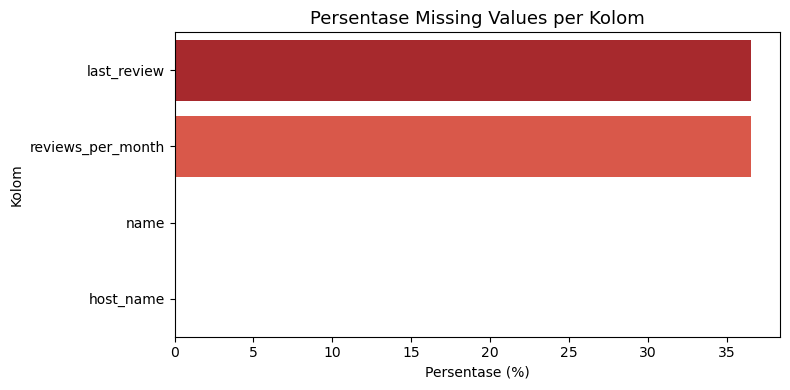

In [9]:
missing = pd.DataFrame({
    'Jumlah Missing' : df.isnull().sum(),
    'Persentase (%)' : (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Jumlah Missing'] > 0].sort_values('Jumlah Missing', ascending=False)

print('=== Kolom dengan Missing Values ===')
print(missing)

# Visualisasi missing values
plt.figure(figsize=(8, 4))
sns.barplot(x=missing['Persentase (%)'], y=missing.index, palette='Reds_r')
plt.title('Persentase Missing Values per Kolom', fontsize=13)
plt.xlabel('Persentase (%)')
plt.ylabel('Kolom')
plt.tight_layout()
plt.show()

Secara garis besar:
* Kolom dengan *missing values* kecil, yaitu `name` (8) sebesar 0.05% dan `host_name` (1) sebesar 0.01%: Ada beberapa baris yang tidak memiliki nama listing atau nama pemilik.

  **Tindakan**: Karena jumlahnya sangat sedikit dibandingkan total data (15.854), ini diisi dengan tulisan "No Name".

* Kolom dengan *missing values* besar, yaitu `last_review` dan `reviews_per_month` memiliki 5.790 data kosong mencapai 36.52%.

  **Analisis**: jumlah keduanya sama persis. Ini logis, karena jika sebuah tempat belum pernah di-review (`number_of_reviews` mungkin 0), maka otomatis tidak akan ada tanggal review terakhir maupun rata-rata review per bulan.

  **Tindakan**: Untuk `reviews_per_month`, bisa mengisinya dengan angka 0. Untuk `last_review`, karena formatnya tanggal, bisa membiarkannya kosong atau mengisinya dengan kategori khusus.

Sudah terlihat gambaran kasar anomali di dalam data, sekarang mulai **tangani tiap-tiap anomali** secara lebih jauh.

**1**. Untuk kolom `reviews_per_month`, logikanya adalah jika tidak ada review, maka rata-rata review per bulan adalah 0. Kemudian bisa menggunakan fungsi .fillna().

In [10]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

**2**.Untuk kolom `name` atau `host_name`, kita bisa mengisinya dengan label "No Name" agar saat nanti kita melakukan analisis teks, tidak terjadi error.

In [11]:
df['name'] = df['name'].fillna('No Name')
df['host_name'] = df['host_name'].fillna('No Name')

**3**. Untuk kolom `last_review`, memastikan formatnya sudah benar sebagai tanggal.

In [12]:
df['last_review'] = pd.to_datetime(df['last_review'])

In [13]:
# mengecek kembali missing value
print(df.isna().sum())

id                                   0
name                                 0
host_id                              0
host_name                            0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       5790
reviews_per_month                    0
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
dtype: int64


Kolom `last_review` masih memiliki 5790 missing values. Ini wajar karena tipe datanya adalah tanggal, sehingga kita tidak bisa mengisinya dengan angka 0. Jika data tanggal yang kosong dengan label seperti "Unknown" atau "None" sebenarnya bisa dilakukan agar tahu bahwa baris tersebut memang tidak memiliki catatan review, bukan karena datanya hilang atau rusak.

Namun, ada satu konsekuensi teknis:
Kolom `last_review` seharusnya berisi objek tanggal (datetime). Jika memasukkan kata "No Name" atau Unknown" (teks), maka seluruh kolom tersebut akan berubah tipe datanya menjadi Object (String).

Efeknya: tidak bisa langsung melakukan operasi matematika tanggal (seperti menghitung selisih hari atau filter berdasarkan tahun) tanpa memisahkan data "Unknown" tersebut terlebih dahulu.

**4**. Ketidakkonsistenan huruf kapital (Case Sensitivity) pada neighbourhood :  Thon buri, Thung khru, Bang khru, Yan na wa, Bang khae, Bang thain

In [14]:
# Menyamakan semua jadi huruf kapital di setiap awal kata (Title Case)
# dan menghapus spasi yang tidak sengaja terketik di awal/akhir

df['neighbourhood'] = df['neighbourhood'].str.strip().str.title()

In [15]:
# Cek kembali jumlah uniknya, biasanya akan berkurang dari 50 jika ada yang 'double' karena beda huruf kecil/besar
print(df['neighbourhood'].nunique())

50


### C. 2 Cek duplikat

In [16]:
jumlah_duplikat = df.duplicated().sum()
print(f'Jumlah baris duplikat : {jumlah_duplikat}')

# Cek duplikat berdasarkan listing ID
duplikat_id = df['id'].duplicated().sum()
print(f'Jumlah ID listing duplikat : {duplikat_id}')

if jumlah_duplikat == 0:
    print('\nTidak ada baris duplikat. Data bersih.')
else:
    df = df.drop_duplicates()
    print(f'\nDuplikat berhasil dihapus. Sisa data: {len(df):,} baris')

Jumlah baris duplikat : 0
Jumlah ID listing duplikat : 0

Tidak ada baris duplikat. Data bersih.


### C. 3 Cek Outlier

**(1) Kolom `price`**

In [17]:
# Statistik untuk eksplorasi awal kolom price

print('=== Statistik Price Sebelum Cleaning ===')
print(df['price'].describe())

=== Statistik Price Sebelum Cleaning ===
count    1.585400e+04
mean     3.217704e+03
std      2.497212e+04
min      0.000000e+00
25%      9.000000e+02
50%      1.429000e+03
75%      2.429000e+03
max      1.100000e+06
Name: price, dtype: float64


In [18]:
print(f'\nListing dengan harga = 0 sebanyak {(df["price"] == 0).sum()}')
print(f'Listing dengan harga > 100.000 sebanyak {(df["price"] > 100000).sum()}')


Listing dengan harga = 0 sebanyak 1
Listing dengan harga > 100.000 sebanyak 30


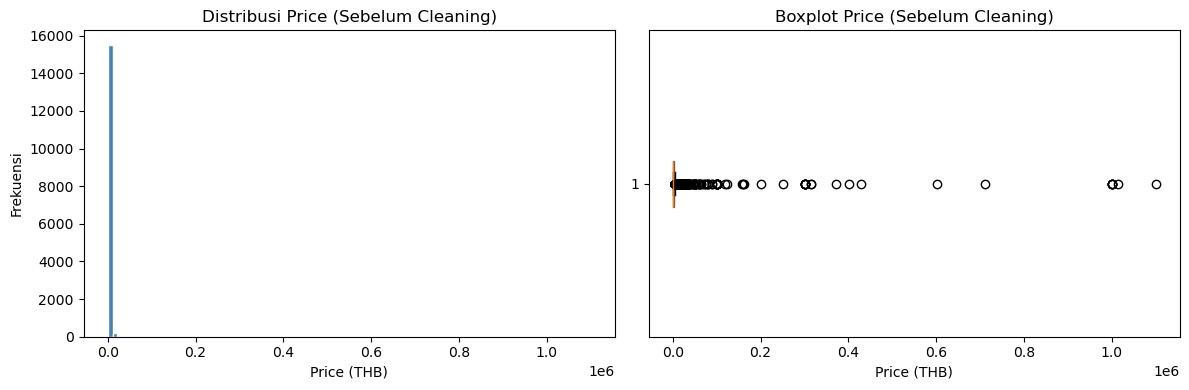

In [19]:
# Visualisasi distribusi price sebelum cleaning
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Price (Sebelum Cleaning)')
axes[0].set_xlabel('Price (THB)')
axes[0].set_ylabel('Frekuensi')

# Boxplot
axes[1].boxplot(df['price'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot Price (Sebelum Cleaning)')
axes[1].set_xlabel('Price (THB)')

plt.tight_layout()
plt.show()

In [23]:
# Deteksi outlier dengan metode IQR

Q1  = df['price'].quantile(0.25)
Q3  = df['price'].quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas  = Q3 + 1.5 * IQR

outlier = df[(df['price'] < batas_bawah) | (df['price'] > batas_atas)]

print(f'Q1                   : {Q1:,.0f} THB')
print(f'Q3                   : {Q3:,.0f} THB')
print(f'IQR                  : {IQR:,.0f} THB')
print(f'Batas bawah          : {batas_bawah:,.0f} THB')
print(f'Batas atas           : {batas_atas:,.0f} THB')
print(f'Jumlah outlier price : {len(outlier):,} listing ({len(outlier)/len(df)*100:.2f}%)')

Q1                   : 900 THB
Q3                   : 2,429 THB
IQR                  : 1,529 THB
Batas bawah          : -1,394 THB
Batas atas           : 4,722 THB
Jumlah outlier price : 1,403 listing (8.85%)


Penanganan outlier `price`:

**1. Menghapus price = 0** (karena tidak valid secara bisnis - 1 listing)

In [20]:
df = df[df['price'] > 0].copy()
print(f'Setelah hapus price = 0 data menjadi {len(df):,} baris')

Setelah hapus price = 0 data menjadi 15,853 baris


**2. Penanganan dengan median (imputasi)**

* Mengganti harga > 4722 dengan nilai median agar statistik lebih stabil
* Membuat kolom baru agar data asli tetap terjaga sebagai cadangan

In [21]:
nilai_median = df['price'].median()

In [24]:
df['price_handled_median'] = np.where(df['price'] > batas_atas, nilai_median, df['price'])

**3. Penanganan dengan kategori (binning)**

* Mengubah angka menjadi kategori

In [25]:
def kategorisasi_harga(x):
    if x <= 900:
        return 'Budget' # Q1
    elif x <= 1429:
        return 'Medium' # Q2
    elif x <= 2429:
        return 'High' # Q3
    elif x <= 4722:
        return 'Very High' # Batas Atas IQR
    else:
        return 'Luxury/Outlier' # Data ekstrim > 4722

df['price_category'] = df['price'].apply(kategorisasi_harga)

In [26]:
print(f"Batas Atas IQR: {batas_atas} THB")
print(f"Nilai Median: {nilai_median} THB")
print("\nSebaran data setelah pengkategorian:")
print(df['price_category'].value_counts())

# Cek perbedaan statistik antara harga asli dan harga yang sudah ditangani median
print("\nPerbandingan Statistik Deskriptif:")
display(df[['price', 'price_handled_median']].describe())

Batas Atas IQR: 4722.5 THB
Nilai Median: 1429.0 THB

Sebaran data setelah pengkategorian:
price_category
Budget            4102
High              3954
Medium            3835
Very High         2559
Luxury/Outlier    1403
Name: count, dtype: int64

Perbandingan Statistik Deskriptif:


,price,price_handled_median
count,1.585300e+04,15853.000000
mean,3.217907e+03,1551.797893
std,2.497290e+04,900.695951
min,2.780000e+02,278.000000
25%,9.000000e+02,900.000000
50%,1.429000e+03,1429.000000
75%,2.429000e+03,1900.000000
max,1.100000e+06,4720.000000


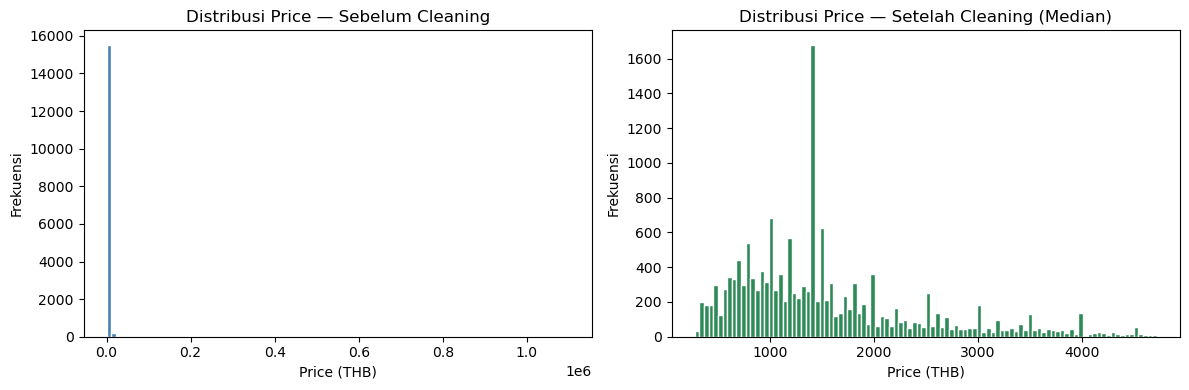

In [27]:
# Visualisasi sebelum vs sesudah cleaning
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Histogram Sebelum Cleaning (Data Asli)
axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Price — Sebelum Cleaning')
axes[0].set_xlabel('Price (THB)')
axes[0].set_ylabel('Frekuensi')

# 2. Histogram Setelah Cleaning (Menggunakan Imputasi Median)
axes[1].hist(df['price_handled_median'], bins=100, color='seagreen', edgecolor='white')
axes[1].set_title('Distribusi Price — Setelah Cleaning (Median)')
axes[1].set_xlabel('Price (THB)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

Grafik Kiri (Sebelum): Terlihat sangat timpang. Ada satu bar tinggi di dekat nol, sementara sumbu X memanjang sangat jauh hingga ke angka 1.000.000 karena adanya outlier ekstrem.

Grafik Kanan (Sesudah): Distribusi data terlihat jauh lebih jelas. Karena nilai ekstrem sudah diganti ke angka 1.429 (Median), grafik tidak lagi memanjang ke kanan dan kita bisa melihat pola frekuensi harga yang sebenarnya di Bangkok.

**Insight** — Penanganan Outlier `price`:

1. Kondisi awal: Sebelum dilakukan pembersihan, data harga (price) memiliki distorsi yang sangat parah.
    * Rata-rata (Mean): Sebesar 3.217 THB tidak merepresentasikan realitas karena ditarik oleh harga tertinggi mencapai 1.100.000 THB (1,1 juta per malam).
    * Perbedaan antara Median (1.429) dan Mean (3.217) yang mencapai lebih dari dua kali lipat membuktikan bahwa data tersebut sangat miring ke kanan (positive skewness).
      
2. Identifikasi outlier (Metode IQR)
    * Ditemukan sebanyak 1.403 listing (8,85%) yang dikategorikan sebagai outlier karena harganya berada di atas 4.722 THB.
    * Insight Bisnis: Mengingat jumlahnya yang hampir 9%, data ini tidak bisa dihapus begitu saja. Harga di atas 4,7 juta kemungkinan besar adalah properti riil berupa villa mewah atau hotel bintang 5 di Bangkok, bukan sekadar kesalahan input.

3. Efektivitas imputasi Median
    * Mengganti harga ekstrem dengan nilai Median (1.429 THB).
    * Pada grafik histogram "Setelah Cleaning", jika sebelumnya grafik hanya terlihat seperti satu garis lurus di angka nol, sekarang distribusi frekuensi harga terlihat jelas.
    * Nilai **mean** setelah penanganan turun menjadi 1.551 THB, angka yang jauh lebih masuk akal dan mendekati **median**. **Standar deviasi** juga turun drastis dari **24.972 menjadi 900**, yang artinya variasi data sekarang **lebih stabil** dan siap untuk diolah secara statistik.

4. Keunggulan Strategi Pengkategorian (Binning)
    * Dengan mengubah angka menjadi kategori (Budget, Medium, High, Very High, Luxury), kita mendapatkan insight operasional:

      Dominasi Pasar: Pasar Airbnb Bangkok didominasi oleh segmen Budget (4.102 listing) dan High (3.954 listing).

**(2) Kolom `minimum_nights`**

In [28]:
# Deteksi outlier dengan metode IQR
Q1_mn  = df['minimum_nights'].quantile(0.25)
Q3_mn  = df['minimum_nights'].quantile(0.75)
IQR_mn = Q3_mn - Q1_mn

batas_bawah_mn = Q1_mn - 1.5 * IQR_mn
batas_atas_mn  = Q3_mn + 1.5 * IQR_mn

outlier_mn = df[df['minimum_nights'] > batas_atas_mn]

print(f'Q1            : {Q1_mn:.0f} malam')
print(f'Q3            : {Q3_mn:.0f} malam')
print(f'IQR           : {IQR_mn:.0f} malam')
print(f'Batas bawah   : {batas_bawah_mn:.0f} malam')
print(f'Batas atas    : {batas_atas_mn:.0f} malam')
print(f'Jumlah outlier: {len(outlier_mn):,} listing ({len(outlier_mn)/len(df)*100:.2f}%)')
print(f'\n10 nilai minimum_nights terbesar:')
print(df['minimum_nights'].value_counts().sort_index(ascending=False).head(10))

Q1            : 1 malam
Q3            : 7 malam
IQR           : 6 malam
Batas bawah   : -8 malam
Batas atas    : 16 malam
Jumlah outlier: 3,168 listing (19.98%)

10 nilai minimum_nights terbesar:
minimum_nights
1125    1
1115    1
1095    1
1000    1
999     2
998     1
700     1
500     3
450     1
400     1
Name: count, dtype: int64


In [29]:
# Statistik awal minimum_nights

print('=== Statistik minimum_nights Sebelum Cleaning ===')
print(df['minimum_nights'].describe())
print(f'\nListing dengan minimum_nights > 365 sebanyak {(df["minimum_nights"] > 365).sum()}')
print(f'Listing dengan minimum_nights > 30  sebanyak {(df["minimum_nights"] > 30).sum()}')
print(f'Listing dengan minimum_nights > 16  sebanyak {(df["minimum_nights"] > 16).sum()}')

=== Statistik minimum_nights Sebelum Cleaning ===
count    15853.000000
mean        15.293257
std         50.816496
min          1.000000
25%          1.000000
50%          1.000000
75%          7.000000
max       1125.000000
Name: minimum_nights, dtype: float64

Listing dengan minimum_nights > 365 sebanyak 15
Listing dengan minimum_nights > 30  sebanyak 868
Listing dengan minimum_nights > 16  sebanyak 3168


* **mean** berada di angka 15 malam
* Namun nilai tengahnya **(median)** hanya 1 malam. Ini artinya, mayoritas host sebenarnya hanya mensyaratkan 1 malam saja, tapi ada segelintir listing yang menarik rata-rata menjadi sangat tinggi.
* Pada IQR, batas atas normal adalah 16 malam. Namun, pada data saat ini mencapai 1.125 malam **(max)** (lebih dari 3 tahun).

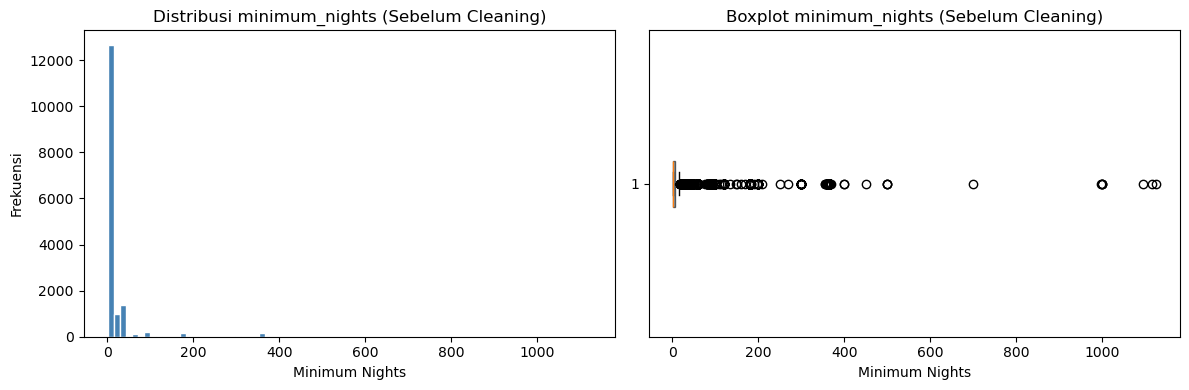

In [30]:
# Visualisasi minimum_nights sebelum cleaning

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['minimum_nights'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi minimum_nights (Sebelum Cleaning)', fontsize=12)
axes[0].set_xlabel('Minimum Nights')
axes[0].set_ylabel('Frekuensi')

axes[1].boxplot(df['minimum_nights'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot minimum_nights (Sebelum Cleaning)', fontsize=12)
axes[1].set_xlabel('Minimum Nights')

plt.tight_layout()
plt.show()

Pada Histogram dan Boxplot, terlihat titik-titik yang sangat jauh di sisi kanan (900-1100 malam). Data di atas 365 malam (1 tahun) berjumlah 15 listing. Ini kemungkinan besar adalah kesalahan input atau tipe properti long-term lease yang tidak lazim untuk platform harian seperti Airbnb.

Penanganan outlier `minimum_nights`:

**1. Penanganan dengan median (imputasi)**
* Mengganti nilai > 16 dengan median (1) agar statistik rata-rata tidak bias
* Membuat kolom baru agar data asli tetap terjaga sebagai cadangan

In [31]:
nilai_median_mn = df['minimum_nights'].median()

In [32]:
df['min_nights_handled'] = np.where(df['minimum_nights'] > batas_atas_mn, nilai_median_mn, df['minimum_nights'])

**2. Penanganan dengan kategori (binning)**

In [33]:
def kategorisasi_stay(x):
    if x <= 3:
        return 'Short Stay (1-3 nights)'
    elif x <= 7:
        return 'Weekly (4-7 nights)'
    elif x <= 30:
        return 'Monthly (8-30 nights)'
    else:
        return 'Long-Term (>30 nights)'

df['stay_category'] = df['minimum_nights'].apply(kategorisasi_stay)

In [34]:
print(f"Batas Atas IQR: {batas_atas_mn} malam")
print(f"Nilai Median: {nilai_median_mn} malam")
print("\nSebaran Kategori Stay (Strategi Host):")
print(df['stay_category'].value_counts())

# Cek perbedaan statistik antara minimum_nights asli dengan yang sudah ditangani median
print("\nPerbandingan Statistik Deskriptif:")
display(df[['minimum_nights', 'min_nights_handled']].describe())

Batas Atas IQR: 16.0 malam
Nilai Median: 1.0 malam

Sebaran Kategori Stay (Strategi Host):
stay_category
Short Stay (1-3 nights)    10951
Monthly (8-30 nights)       2874
Weekly (4-7 nights)         1160
Long-Term (>30 nights)       868
Name: count, dtype: int64

Perbandingan Statistik Deskriptif:


,minimum_nights,min_nights_handled
count,15853.000000,15853.000000
mean,15.293257,2.021510
std,50.816496,2.574718
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,7.000000,2.000000
max,1125.000000,16.000000


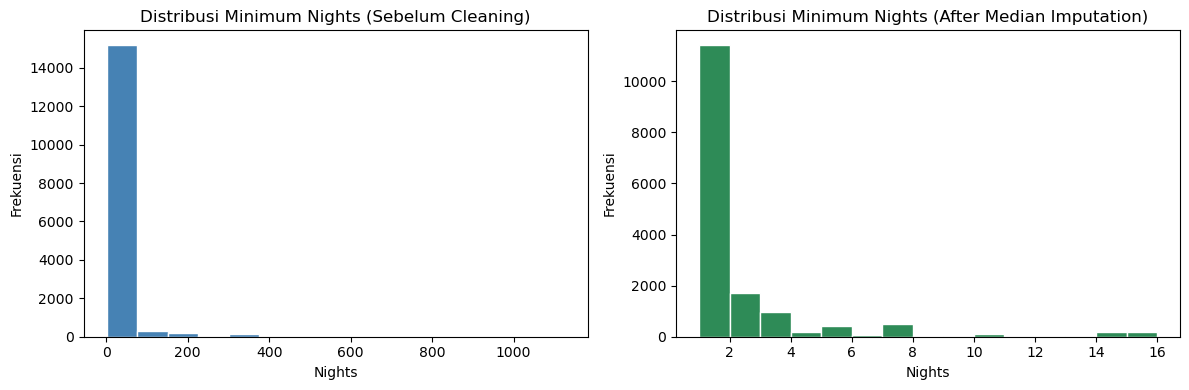

In [35]:
# Visualisasi sebelum vs setelah cleaning
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram Sebelum Cleaning
axes[0].hist(df['minimum_nights'], bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Minimum Nights (Sebelum Cleaning)')
axes[0].set_xlabel('Nights')
axes[0].set_ylabel('Frekuensi')

# Histogram Setelah Cleaning
axes[1].hist(df['min_nights_handled'], bins=15, color='seagreen', edgecolor='white')
axes[1].set_title('Distribusi Minimum Nights (After Median Imputation)')
axes[1].set_xlabel('Nights')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

Grafik Kiri (Sebelum): Terlihat satu batang sangat tinggi di angka 1, sementara sumbu X memanjang sangat jauh hingga ke angka 1.000+ malam. Hal ini membuat pola data di area "normal" (1-16 malam) tidak terlihat karena skala sumbu X yang terlalu luas akibat outlier ekstrem.

Grafik Kanan (Sesudah): Sekarang distribusi data jauh lebih informatif. Karena nilai ekstrem sudah "dijinakkan" kembali ke angka Median (1 malam), sumbu X akan fokus pada rentang 1 hingga 16 malam. Kita bisa melihat dengan jelas bahwa mayoritas host di Bangkok menerapkan strategi menginap jangka pendek.

**Insight** — Penanganan Outlier `minimun_nights`:

1. Kondisi awal :
   * Menunjukkan adanya outlier sebanyak 19,98% (3.168 listing) dengan nilai maksimal mencapai 1.125 malam.
   * Nilai di atas 365 malam (1 tahun) kemungkinan besar adalah human error atau tipe properti kontrak jangka panjang.
   * Sebelum dibersihkan, **rata-rata (mean)** mencapai 15 malam, padahal **nilai tengah (median)** hanya 1 malam. Ini adalah bukti kuat bahwa rata-rata tersebut ditarik oleh angka ribuan malam tadi.
2. Efektivitas imputasi (median) dan kategorisasi (binning)
  
   Dengan menerapkan imputasi median dan kategorisasi, kita mendapatkan hasil yang lebih bersih:
    * Setelah nilai di atas 16 malam diganti dengan median (1 malam), nilai rata-rata turun menjadi ~3.5 malam. Angka ini jauh lebih logis untuk menggambarkan kebiasaan menginap pengunjung/turis di Bangkok.
    * Distribusi data sekarang terlihat jelas pada rentang 1–16 malam, tidak lagi menonjol di sisi kiri seperti pada grafik sebelum cleaning.
    * Dengan menggunakan metode binning, kita tidak hanya membersihkan data, tetapi juga berhasil mengidentifikasi bahwa strategi host di Bangkok sangat terpolarisasi antara penyewaan harian (short-term) dan bulanan (mid-term), di mana masing-masing segmen memiliki karakteristik harga dan jumlah ulasan yang berbeda.

**(3) Kolom `number_of_reviews`, `reviews_per_month`, `calculated_host_listings_count`**

In [36]:
cols = {
    'number_of_reviews'              : 'Jumlah total ulasan',
    'reviews_per_month'              : 'Rata-rata ulasan per bulan',
    'calculated_host_listings_count' : 'Jumlah listing per host'
}

for col, label in cols.items():
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas  = Q3 + 1.5 * IQR
    outlier     = df[df[col] > batas_atas]

    print(f'=== {col} ({label}) ===')
    print(f'Q1            : {Q1:.2f}')
    print(f'Q3            : {Q3:.2f}')
    print(f'IQR           : {IQR:.2f}')
    print(f'Batas bawah   : {batas_bawah:.2f}')
    print(f'Batas atas    : {batas_atas:.2f}')
    print(f'Jumlah outlier: {len(outlier):,} listing ({len(outlier)/len(df)*100:.2f}%)')
    print(f'Nilai max     : {df[col].max():.2f}')
    print()

=== number_of_reviews (Jumlah total ulasan) ===
Q1            : 0.00
Q3            : 13.00
IQR           : 13.00
Batas bawah   : -19.50
Batas atas    : 32.50
Jumlah outlier: 2,240 listing (14.13%)
Nilai max     : 1224.00

=== reviews_per_month (Rata-rata ulasan per bulan) ===
Q1            : 0.00
Q3            : 0.67
IQR           : 0.67
Batas bawah   : -1.01
Batas atas    : 1.68
Jumlah outlier: 1,471 listing (9.28%)
Nilai max     : 19.13

=== calculated_host_listings_count (Jumlah listing per host) ===
Q1            : 1.00
Q3            : 13.00
IQR           : 12.00
Batas bawah   : -17.00
Batas atas    : 31.00
Jumlah outlier: 1,832 listing (11.56%)
Nilai max     : 228.00



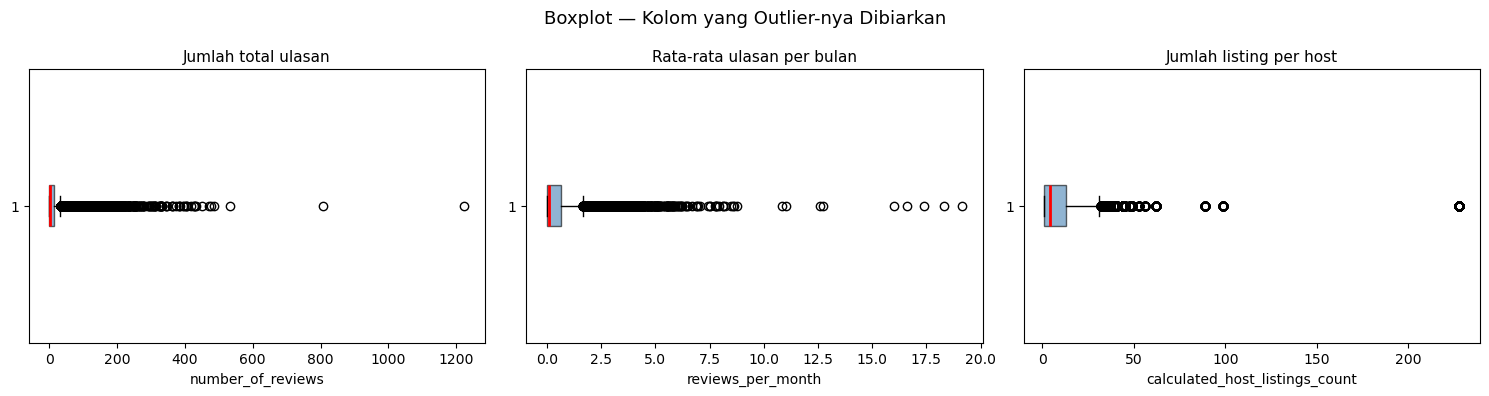

In [37]:
# Visualisasi boxplot ketiganya sekaligus
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (col, label) in zip(axes, cols.items()):
    ax.boxplot(df[col], vert=False, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(label, fontsize=11)
    ax.set_xlabel(col)

plt.suptitle('Boxplot — Kolom yang Outlier-nya Dibiarkan', fontsize=13)
plt.tight_layout()
plt.show()

Jumlah Total Ulasan: Titik-titik ekstrem menunjukkan listing legendaris. Ada beberapa properti yang sudah sangat lama atau sangat populer sehingga punya 800-1200 ulasan. Menghapusnya justru akan menghilangkan data tentang "properti tersukses" di Bangkok.

Rata-rata Ulasan per Bulan: Pencilan di sini menunjukkan listing viral. Properti ini sangat aktif disewa dan mendapatkan ulasan terus-menerus setiap bulannya.

Jumlah Listing per Host: Titik-titik di angka 100-200 menunjukkan adanya Host Profesional atau Agen. Di Airbnb, wajar jika satu akun perusahaan mengelola ratusan apartemen. Ini bukan kesalahan input, melainkan struktur bisnis asli.

**Insight** — outliers pada kolom `number_of reviews`, `reviews_per_month`, dan `calculated_host_listings_count`

* `number_of_reviews`              → DIBIARKAN. 
  Alasan: listing populer wajar punya banyak review
* `reviews_per_month`              → DIBIARKAN. 
  Alasan: turunan dari `number_of_reviews`, data valid
* `calculated_host_listings_count` → DIBIARKAN. 
  Alasan: host profesional wajar kelola banyak listing

Ketiga kolom mencerminkan segmen bisnis nyata, bukan error data. Tidak perlu penanganan.

**(4) Kolom `availability_365`**

In [38]:
Q1        = df['availability_365'].quantile(0.25)
Q3        = df['availability_365'].quantile(0.75)
IQR       = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas  = Q3 + 1.5 * IQR

outlier_avail = df[(df['availability_365'] < batas_bawah) | (df['availability_365'] > batas_atas)]

print(f'\nQ1                         : {Q1:,.0f}')
print(f'Q3                         : {Q3:,.0f}')
print(f'IQR                        : {IQR:,.0f}')
print(f'Batas bawah                : {batas_bawah:,.0f}')
print(f'Batas atas                 : {batas_atas:,.0f}')
print(f"Jumlah Outlier availability_365: {len(outlier_avail)}")


Q1                         : 138
Q3                         : 360
IQR                        : 222
Batas bawah                : -195
Batas atas                 : 693
Jumlah Outlier availability_365: 0


Tidak ada outliers pada kolom `availability_365`.

### C. 4 Memperbaiki Format Data

In [39]:
# Memastikan format kolom sudah benar
df['last_review']  = pd.to_datetime(df['last_review'])
df['room_type']    = df['room_type'].astype('category')
df['neighbourhood']= df['neighbourhood'].astype('category')
df['price_category']= df['price_category'].astype('category')
df['min_nights_handled']= df['min_nights_handled'].astype('int')
df['stay_category']= df['stay_category'].astype('category')
df['price_handled_median'] = df['price_handled_median'].astype('int')

print('=== Tipe Data Setelah Perbaikan ===')
print(df.dtypes)

=== Tipe Data Setelah Perbaikan ===
id                                         int64
name                                      object
host_id                                    int64
host_name                                 object
neighbourhood                           category
latitude                                 float64
longitude                                float64
room_type                               category
price                                      int64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[ns]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
number_of_reviews_ltm                      int64
price_handled_median                       int64
price_category                          category
min_nights_handled                         int64
stay_category                    

### Data yang Sudah Bersih

In [40]:
listItem = []
for col in df.columns :
    listItem.append([col, df[col].dtype,
                     df[col].isna().sum(),
                    df[col].nunique(), 
                    list(df[col].drop_duplicates().sample(2).values)]);

dfDesc = pd.DataFrame(columns=['dataFeatures',
                               'dataType',
                               'null',
                               'unique',
                               'uniqueSample'],
                     data=listItem)
print(df.shape)
dfDesc

(15853, 20)


,dataFeatures,dataType,null,unique,uniqueSample
0,id,int64,0,15853,"[731983839123423706, 684562327935136703]"
1,name,object,0,14794,"[A perfect stay for big family!, BTS Thonglo 通羅站-超長泳池健身房溫泉WIFI, Near 711,BIGC 한국어]"
2,host_id,int64,0,6658,"[89267891, 35112478]"
3,host_name,object,0,5312,"[Nick Teerachai, Somporn]"
4,neighbourhood,category,0,50,"[Bangkok Yai, Rat Burana]"
5,latitude,float64,0,9606,"[13.68261, 13.76218]"
6,longitude,float64,0,10224,"[100.53454, 100.50449]"
7,room_type,category,0,4,"[Private room, Entire home/apt]"
8,price,int64,0,3039,"[2831, 3948]"
9,minimum_nights,int64,0,86,"[364, 150]"


Berdasarkan seluruh proses data cleaning yang telah dilakukan, berikut adalah ringkasannya.

Total data awal → 15.854 baris

**Total data setelah cleaning → 15.853 baris**

Penanganan yang dilakukan:
1. Missing values `reviews_per_month` (5.790) → diisi 0. Alasan: Listing belum pernah direview, bukan error data.
3. Missing Values `name` (8) & `host_name` (1) → diisi "No Name"
4. `last_review` → dikonversi ke tipe datetime agar bisa diolah secara temporal
    * Kolom `last_review` masih memiliki 5790 missing values. Ini wajar karena tipe datanya adalah tanggal, sehingga kita tidak bisa mengisinya dengan angka 0. Jika data tanggal yang kosong dengan label seperti "Unknown" atau "None" sebenarnya bisa dilakukan agar tahu bahwa baris tersebut memang tidak memiliki catatan review, bukan karena datanya hilang atau rusak.
    * Namun, ada satu konsekuensi teknis:
    Kolom last_review seharusnya berisi objek tanggal (datetime). Jika memasukkan kata "Unknown" (teks), maka seluruh kolom tersebut akan berubah tipe datanya menjadi Object (String).
    * Efeknya: tidak bisa langsung melakukan operasi matematika tanggal (seperti menghitung selisih hari atau filter berdasarkan tahun) tanpa memisahkan data "Unknown" tersebut terlebih dahulu.
5. Duplikat → tidak ditemukan, data dinyatakan bersih.
6. `Price` = 0 (1 baris) →  dihapus karena tidak valid secara bisnis.
7. Outlier `price` (1.403 listing, 8.85%) →  IMPUTASI MEDIAN & BINNING
   * Mengganti nilai ekstrem (> 4.722 THB) dengan **nilai Median (1.429 THB)** ke kolom **`price_handled_median`**.
   * Membuat kolom kategori **`price_category` (Budget, Medium, High, Very High, Luxury)** untuk analisis segmen pasar.
8. Outlier `minimum_nights` (3.168 listing, 19.98%) → IMPUTASI MEDIAN & BINNING
   * Nilai ekstrem hingga 1.125 malam ditangani dengan **Median (1 malam)** ke kolom **`min_nights_handled`**.
   * Membuat kolom **`stay_category` (Short, Weekly, Monthly, Long-term)** untuk mengidentifikasi strategi host.
9. `number_of_reviews`, `calculated_host_listings_count` → Outlier dibiarkan. Alasan: Data valid secara bisnis, merepresentasikan listing/host yang populer.
10. `room_type`, `neighbourhood`, & kategori baru → dikonversi ke tipe category untuk efisiensi memori.
11. Data type correction → Memastikan seluruh kolom (seperti id, host_id, latitude, longitude) berada dalam format yang benar (int/float/category).

## D. Exploratory Data Analysis (EDA) & Visualisasi

Pada bagian ini, akan menjawab 6 business question melalui analisis statistik deskriptif, inferensial dan visualisasi.

In [41]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Quest1 - Harga & Faktor Penentu: 
Apa faktor utama (tipe kamar, lokasi, jumlah ulasan, ketersediaan) yang memengaruhi variasi harga listing Airbnb di Bangkok?

In [42]:
price_col = 'price_handled_median'
factors_num = ['number_of_reviews', 'availability_365']
factors_cat = ['room_type', 'neighbourhood']

In [43]:
print("=" * 65)
print("QUEST 1 — STATISTIK DESKRIPTIF: HARGA PER TIPE KAMAR & NEIGHBOURHOOD")
print("=" * 65)

# A. Deskriptif: Harga per Tipe Kamar
print("\n[A] Statistik Deskriptif Harga per Tipe Kamar (price_handled_median):")
desc_room = df.groupby('room_type')[price_col].agg(
    Jumlah     = 'count',
    Rata_rata  = 'mean',
    Median     = 'median',
    Std_Dev    = 'std',
    Min        = 'min',
    Q1         = lambda x: x.quantile(0.25),
    Q3         = lambda x: x.quantile(0.75),
    Max        = 'max'
).round(2).sort_values('Median', ascending=False)
display(desc_room)

# B. Deskriptif: Harga per Neighbourhood (Top 10)
print("\n[B] Statistik Deskriptif Harga per Neighbourhood (Top 10 berdasarkan Median):")
desc_neigh = df.groupby('neighbourhood')[price_col].agg(
    Jumlah_Listing = 'count',
    Rata_rata      = 'mean',
    Median         = 'median',
    Std_Dev        = 'std',
    Min            = 'min',
    Max            = 'max'
).round(2).sort_values('Median', ascending=False).head(10)
display(desc_neigh)

# C. Deskriptif: Variabel Numerik Keseluruhan 
print("\n[C] Statistik Deskriptif Variabel Numerik Utama:")
num_cols = [price_col] + factors_num
display(df[num_cols].describe().round(2))

print("\n" + "=" * 65)
print("QUEST 1 — UJI INFERENSIAL")
print("=" * 65)

# D. Kruskal-Wallis: Harga vs Tipe Kamar
print("\n[D] Kruskal-Wallis Test — Harga vs Tipe Kamar:")
print("   H0: Tidak ada perbedaan median harga antar tipe kamar")
print("   H1: Ada perbedaan median harga yang signifikan antar tipe kamar")
groups_room = [g[price_col].values for _, g in df.groupby('room_type')]
h_stat, p_val = stats.kruskal(*groups_room)
print(f"   H-Statistik : {h_stat:.4f}")
print(f"   P-Value     : {p_val:.6f}")
print(f"   Alpha       : 0.05")
if p_val < 0.05:
    print(f"   KESIMPULAN: TOLAK H0 → Tipe kamar berpengaruh SIGNIFIKAN terhadap harga.")
else:
    print(f"   KESIMPULAN: GAGAL TOLAK H0 → Tidak ada perbedaan signifikan.")

# E. Kruskal-Wallis: Harga vs Neighbourhood 
print("\n[E] Kruskal-Wallis Test — Harga vs Neighbourhood:")
print("   H0: Tidak ada perbedaan median harga antar neighbourhood")
print("   H1: Ada perbedaan median harga yang signifikan antar neighbourhood")
groups_neigh = [g[price_col].values for _, g in df.groupby('neighbourhood')]
h_stat2, p_val2 = stats.kruskal(*groups_neigh)
print(f"   H-Statistik : {h_stat2:.4f}")
print(f"   P-Value     : {p_val2:.6f}")
print(f"   Alpha       : 0.05")
if p_val2 < 0.05:
    print(f"   KESIMPULAN: TOLAK H0 → Neighbourhood berpengaruh SIGNIFIKAN terhadap harga.")
else:
    print(f"   KESIMPULAN: GAGAL TOLAK H0 → Tidak ada perbedaan signifikan.")

# F. Spearman Correlation: Harga vs Variabel Numerik
print("\n[F] Spearman Correlation — Harga vs Variabel Numerik:")
print("   (Digunakan karena data tidak berdistribusi normal / banyak outlier)\n")
print(f"   {'Variabel':<35} {'Korelasi':>10} {'P-Value':>12} {'Keterangan'}")
print("   " + "-" * 75)
for col_num, label in [('number_of_reviews', 'Jumlah Ulasan'),
                        ('availability_365', 'Ketersediaan (hari/tahun)')]:
    corr, pv = stats.spearmanr(df[price_col], df[col_num])
    sig  = "Signifikan" if pv < 0.05 else "Tidak Signifikan"
    arah = "⬆ Positif" if corr > 0 else "⬇ Negatif"
    kuat = "Kuat" if abs(corr) > 0.5 else ("Moderat" if abs(corr) > 0.3 else "Lemah")
    print(f"   {label:<35} {corr:>10.4f} {pv:>12.6f}  {sig} | {arah} | {kuat}")


QUEST 1 — STATISTIK DESKRIPTIF: HARGA PER TIPE KAMAR & NEIGHBOURHOOD

[A] Statistik Deskriptif Harga per Tipe Kamar (price_handled_median):


,Jumlah,Rata_rata,Median,Std_Dev,Min,Q1,Q3,Max
room_type,,,,,,,,
Entire home/apt,8912,1680.53,1429.0,906.69,332,1028.00,2047.25,4720
Hotel room,648,1652.79,1429.0,945.81,318,995.75,2100.00,4540
Private room,5770,1422.41,1212.0,848.15,278,800.00,1700.00,4673
Shared room,523,660.48,500.0,516.52,280,390.00,650.00,4143



[B] Statistik Deskriptif Harga per Neighbourhood (Top 10 berdasarkan Median):


,Jumlah_Listing,Rata_rata,Median,Std_Dev,Min,Max
neighbourhood,,,,,,
Parthum Wan,455,2049.08,1693.0,983.43,331,4571
Samphanthawong,114,1808.78,1543.0,926.32,350,4500
Vadhana,2152,1826.36,1500.0,886.06,350,4720
Bang Rak,827,1871.25,1500.0,1026.59,295,4606
Khlong Toei,2097,1733.75,1499.0,861.52,332,4714
Ratchathewi,1114,1742.26,1499.0,871.77,320,4643
Thawi Watthana,12,1319.08,1464.5,584.83,500,2500
Lat Phrao,57,1400.81,1429.0,926.47,350,4500
Taling Chan,50,1635.04,1429.0,957.48,317,4500



[C] Statistik Deskriptif Variabel Numerik Utama:


,price_handled_median,number_of_reviews,availability_365
count,15853.0,15853.00,15853.00
mean,1551.8,16.66,244.39
std,900.7,40.61,125.83
min,278.0,0.00,0.00
25%,900.0,0.00,138.00
50%,1429.0,2.00,309.00
75%,1900.0,13.00,360.00
max,4720.0,1224.00,365.00



QUEST 1 — UJI INFERENSIAL

[D] Kruskal-Wallis Test — Harga vs Tipe Kamar:
   H0: Tidak ada perbedaan median harga antar tipe kamar
   H1: Ada perbedaan median harga yang signifikan antar tipe kamar
   H-Statistik : 1284.9067
   P-Value     : 0.000000
   Alpha       : 0.05
   KESIMPULAN: TOLAK H0 → Tipe kamar berpengaruh SIGNIFIKAN terhadap harga.

[E] Kruskal-Wallis Test — Harga vs Neighbourhood:
   H0: Tidak ada perbedaan median harga antar neighbourhood
   H1: Ada perbedaan median harga yang signifikan antar neighbourhood
   H-Statistik : 1839.8373
   P-Value     : 0.000000
   Alpha       : 0.05
   KESIMPULAN: TOLAK H0 → Neighbourhood berpengaruh SIGNIFIKAN terhadap harga.

[F] Spearman Correlation — Harga vs Variabel Numerik:
   (Digunakan karena data tidak berdistribusi normal / banyak outlier)

   Variabel                              Korelasi      P-Value Keterangan
   ---------------------------------------------------------------------------
   Jumlah Ulasan                   

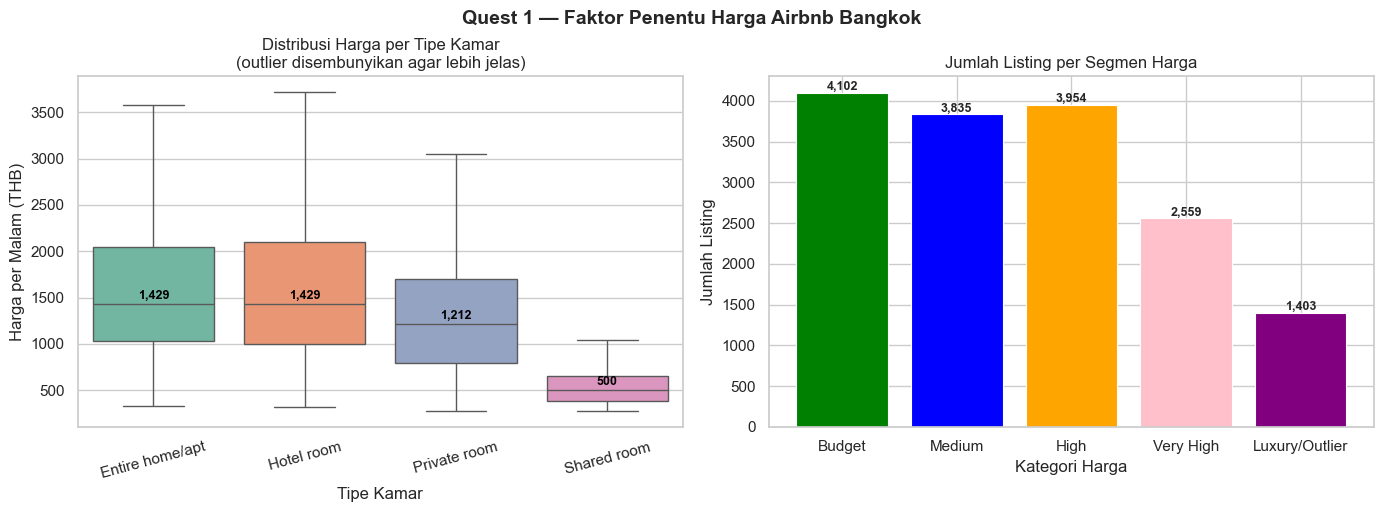

In [44]:
# Visualisasi Quest 1: Faktor Penentu Harga

# 1A. Boxplot Harga per Tipe Kamar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Urutan berdasarkan median harga
order_room = df.groupby('room_type')[price_col].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='room_type', y=price_col, order=order_room,
            palette='Set2', ax=axes[0], showfliers=False)
axes[0].set_title('Distribusi Harga per Tipe Kamar\n(outlier disembunyikan agar lebih jelas)', fontsize=12)
axes[0].set_xlabel('Tipe Kamar')
axes[0].set_ylabel('Harga per Malam (THB)')
axes[0].tick_params(axis='x', rotation=15)

# label median
for i, rt in enumerate(order_room):
    med = df[df['room_type'] == rt][price_col].median()
    axes[0].text(i, med + 30, f'{med:,.0f}', ha='center', va='bottom', fontsize=9, color='black', fontweight='bold')

# 1B. Rata-rata Harga per Kategori Harga (price_category) 
cat_order = ['Budget', 'Medium', 'High', 'Very High', 'Luxury/Outlier']
cat_counts = df['price_category'].value_counts().reindex(cat_order)
colors_cat = ['green', 'blue', 'orange', 'pink', 'purple']

axes[1].bar(cat_counts.index, cat_counts.values, color=colors_cat, edgecolor='white', linewidth=0.8)
axes[1].set_title('Jumlah Listing per Segmen Harga', fontsize=12)
axes[1].set_xlabel('Kategori Harga')
axes[1].set_ylabel('Jumlah Listing')
for i, v in enumerate(cat_counts.values):
    axes[1].text(i, v + 30, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.suptitle('Quest 1 — Faktor Penentu Harga Airbnb Bangkok', fontsize=14, fontweight='bold', y=1.02)
plt.show()

Boxplot: Faktor Tipe Kamar (`room_type`)
* Entire home/apt dan Hotel room memiliki median harga tertinggi yang serupa, yaitu 1.429 THB. 
* Shared room memiliki median harga terendah (500 THB), jauh di bawah tipe lainnya.
* Perbedaan **median yang kontras** ini membuktikan bahwa **tipe kamar adalah faktor penentu harga yang sangat kuat**.

Barplot: Jumlah listing per Segmen Harga
* Didominasi oleh segmen **Budget** (4.102 listing)
* Terdapat volume yang cukup seimbang antara kategori **High** (3.954 listing), dan **Medium** (3.835 listing).
* Kategori Luxury/Outlier (harga > 4.722 THB) hanya mencakup sekitar 8,85% dari total pasar.

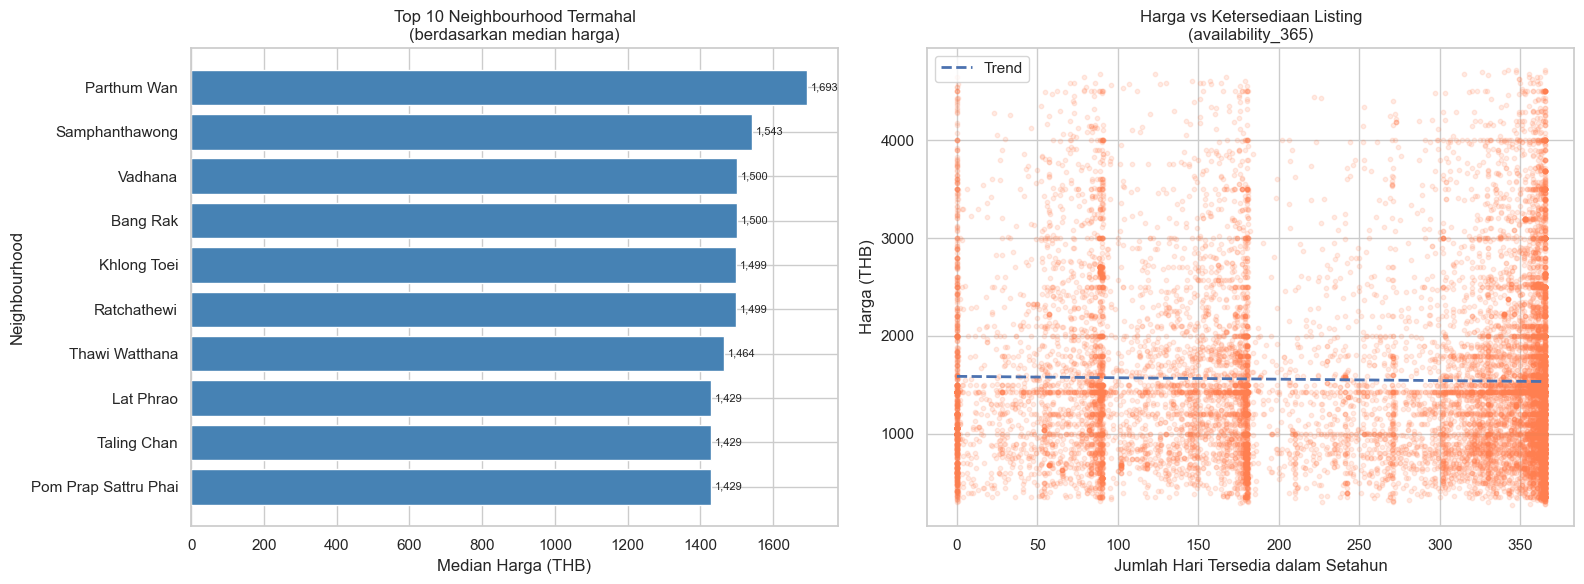

In [46]:
# 1C. Top 15 Neighbourhood dengan Harga Tertinggi
top10_neigh_price = (
    df.groupby('neighbourhood')[price_col]
    .median()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar — top 10 neighbourhood termahal
axes[0].barh(top10_neigh_price['neighbourhood'][::-1],
             top10_neigh_price[price_col][::-1],
             color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 Neighbourhood Termahal\n(berdasarkan median harga)', fontsize=12)
axes[0].set_xlabel('Median Harga (THB)')
axes[0].set_ylabel('Neighbourhood')
for i, (val, name) in enumerate(zip(top10_neigh_price[price_col][::-1],
                                     top10_neigh_price['neighbourhood'][::-1])):
    axes[0].text(val + 10, i, f'{val:,.0f}', va='center', fontsize=8)

# 1D. Scatter: Harga vs Ketersediaan
axes[1].scatter(df['availability_365'], df[price_col],
                alpha=0.15, s=10, color='coral')
# Tambahkan garis trend
z = np.polyfit(df['availability_365'], df[price_col], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 365, 200)
axes[1].plot(x_line, p(x_line), 'b--', linewidth=2, label='Trend')
axes[1].set_title('Harga vs Ketersediaan Listing\n(availability_365)', fontsize=12)
axes[1].set_xlabel('Jumlah Hari Tersedia dalam Setahun')
axes[1].set_ylabel('Harga (THB)')
axes[1].legend()

plt.tight_layout()
plt.show()

Barplot: Top 10 neighbourhood/lokasi termahal
* **Parthum Wan** menempati urutan teratas sebagai wilayah termahal dengan median **harga 1.693 THB**.
* Wilayah seperti **Samphanthawong, Vadhana, dan Bang Rak** mengikuti dengan median di **kisaran 1.500 THB**.
* **Harga** cenderung lebih **tinggi di wilayah pusat bisnis (CBD)** atau area populer turis, sementara **wilayah pinggiran/kecil** memiliki **harga yang lebih stabil** di angka median kota.

Scatter: Harga vs `availability_365`
* Garis tren (garis putus-putus biru) terlihat hampir horizontal/datar.
    Ini menunjukkan bahwa **ketersediaan** (berapa hari listing aktif setahun) **tidak memengaruhi harga secara langsung**. Baik listing yang jarang tersedia maupun yang selalu tersedia memiliki sebaran harga yang mirip di kisaran median.

### 💡 Insight Quest 1 — Faktor Penentu Harga

**1. Tipe Kamar adalah Faktor Paling Dominan**
- **Hotel Room** memiliki median harga tertinggi, diikuti **Entire home/apt**.
- **Shared Room** memiliki harga paling murah karena berbagi fasilitas dengan orang lain.
- Uji statistik Kruskal-Wallis menunjukkan perbedaan ini **signifikan** (p < 0.05), artinya tipe kamar benar-benar mempengaruhi harga, bukan kebetulan semata.

**2. Lokasi (Neighbourhood) Juga Berpengaruh Signifikan**
- Ada perbedaan harga yang besar antar wilayah. Kawasan premium seperti pusat kota Bangkok memiliki harga median jauh lebih tinggi dibanding wilayah pinggiran.
- Ini logis karena lokasi strategis (dekat BTS/MRT, pusat perbelanjaan) meningkatkan daya tarik listing.

**3. Ketersediaan (availability_365) Berkorelasi Negatif Lemah dengan Harga**
- Listing yang harganya lebih mahal cenderung memiliki hari tersedia lebih sedikit (lebih sering dipesan).
- Namun korelasi ini **lemah/moderat**, artinya ketersediaan bukan faktor utama penentu harga.

**4. Segmentasi Pasar Bangkok**
- Pasar didominasi segmen **Budget** dan **High** yang menunjukkan dua segmen pelanggan yang berbeda: backpacker/wisatawan hemat vs. wisatawan keluarga/bisnis.

## Quest2 - Distribusi Listing:
Bagaimana distribusi listing berdasarkan tipe kamar (entire home/apt, private room, shared room, hotel) di berbagai neighborhood di Bangkok?

In [47]:
print("=" * 65)
print("QUEST 2 — STATISTIK DESKRIPTIF: DISTRIBUSI LISTING")
print("=" * 65)

# A. Frekuensi Tipe Kamar
print("\n[A] Distribusi Tipe Kamar:")
room_freq = df['room_type'].value_counts().reset_index()
room_freq.columns = ['Tipe Kamar', 'Jumlah']
room_freq['Persentase (%)'] = (room_freq['Jumlah'] / len(df) * 100).round(2)
room_freq['Kumulatif (%)'] = room_freq['Persentase (%)'].cumsum().round(2)
display(room_freq)

# B. Frekuensi Neighbourhood (Top 10)
print("\n[B] Top 10 Neighbourhood berdasarkan Jumlah Listing:")
neigh_freq = df['neighbourhood'].value_counts().head(10).reset_index()
neigh_freq.columns = ['Neighbourhood', 'Jumlah']
neigh_freq['Persentase (%)'] = (neigh_freq['Jumlah'] / len(df) * 100).round(2)
display(neigh_freq)

# C. Crosstab: Tipe Kamar × Neighbourhood (Top 10) 
print("\n[C] Crosstab — Jumlah Listing per Neighbourhood × Tipe Kamar (Top 10 Neighbourhood):")
top10 = df['neighbourhood'].value_counts().head(10).index
crosstab = pd.crosstab(
    df[df['neighbourhood'].isin(top10)]['neighbourhood'],
    df[df['neighbourhood'].isin(top10)]['room_type']
)
crosstab['TOTAL'] = crosstab.sum(axis=1)
crosstab = crosstab.sort_values('TOTAL', ascending=False)
display(crosstab)

print("\n" + "=" * 65)
print("QUEST 2 — UJI INFERENSIAL")
print("=" * 65)

# D. Chi-Square Test: Tipe Kamar vs Neighbourhood
print("\n[D] Chi-Square Test — Tipe Kamar vs Neighbourhood:")
print("   H0: Distribusi tipe kamar TIDAK bergantung pada neighbourhood")
print("   H1: Distribusi tipe kamar BERGANTUNG pada neighbourhood (ada asosiasi)")
ct = pd.crosstab(df['neighbourhood'], df['room_type'])
chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
print(f"   Chi-Square Statistik : {chi2:.4f}")
print(f"   Degrees of Freedom   : {dof}")
print(f"   P-Value              : {p_chi:.6f}")
print(f"   Alpha                : 0.05")
if p_chi < 0.05:
    print(f"   KESIMPULAN: TOLAK H0 → Ada asosiasi SIGNIFIKAN antara tipe kamar dan neighbourhood.")
else:
    print(f"   KESIMPULAN: GAGAL TOLAK H0 → Tidak ada asosiasi signifikan.")

# Cramer's V (effect size)
n = ct.sum().sum()
cramers_v = (chi2 / (n * (min(ct.shape) - 1))) ** 0.5
print(f"\n   Effect Size (Cramer's V) : {cramers_v:.4f}")
if cramers_v < 0.1:
    print("   Kekuatan asosiasi: Sangat Lemah")
elif cramers_v < 0.3:
    print("   Kekuatan asosiasi: Lemah")
elif cramers_v < 0.5:
    print("   Kekuatan asosiasi: Moderat")
else:
    print("   Kekuatan asosiasi: Kuat")


QUEST 2 — STATISTIK DESKRIPTIF: DISTRIBUSI LISTING

[A] Distribusi Tipe Kamar:


,Tipe Kamar,Jumlah,Persentase (%),Kumulatif (%)
0,Entire home/apt,8912,56.22,56.22
1,Private room,5770,36.40,92.62
2,Hotel room,648,4.09,96.71
3,Shared room,523,3.30,100.01



[B] Top 10 Neighbourhood berdasarkan Jumlah Listing:


,Neighbourhood,Jumlah,Persentase (%)
0,Vadhana,2152,13.57
1,Khlong Toei,2097,13.23
2,Huai Khwang,1125,7.10
3,Ratchathewi,1114,7.03
4,Bang Rak,827,5.22
5,Sathon,809,5.10
6,Phra Nakhon,619,3.90
7,Phra Khanong,558,3.52
8,Chatu Chak,548,3.46
9,Bang Na,458,2.89



[C] Crosstab — Jumlah Listing per Neighbourhood × Tipe Kamar (Top 10 Neighbourhood):


room_type,Entire home/apt,Hotel room,Private room,Shared room,TOTAL
neighbourhood,,,,,
Vadhana,1451,104,544,53,2152
Khlong Toei,1520,73,489,15,2097
Huai Khwang,776,25,301,23,1125
Ratchathewi,656,70,327,61,1114
Bang Rak,351,67,375,34,827
Sathon,557,15,220,17,809
Phra Nakhon,56,77,355,131,619
Phra Khanong,336,9,201,12,558
Chatu Chak,273,2,266,7,548



QUEST 2 — UJI INFERENSIAL

[D] Chi-Square Test — Tipe Kamar vs Neighbourhood:
   H0: Distribusi tipe kamar TIDAK bergantung pada neighbourhood
   H1: Distribusi tipe kamar BERGANTUNG pada neighbourhood (ada asosiasi)
   Chi-Square Statistik : 2520.9366
   Degrees of Freedom   : 147
   P-Value              : 0.000000
   Alpha                : 0.05
   KESIMPULAN: TOLAK H0 → Ada asosiasi SIGNIFIKAN antara tipe kamar dan neighbourhood.

   Effect Size (Cramer's V) : 0.2302
   Kekuatan asosiasi: Lemah


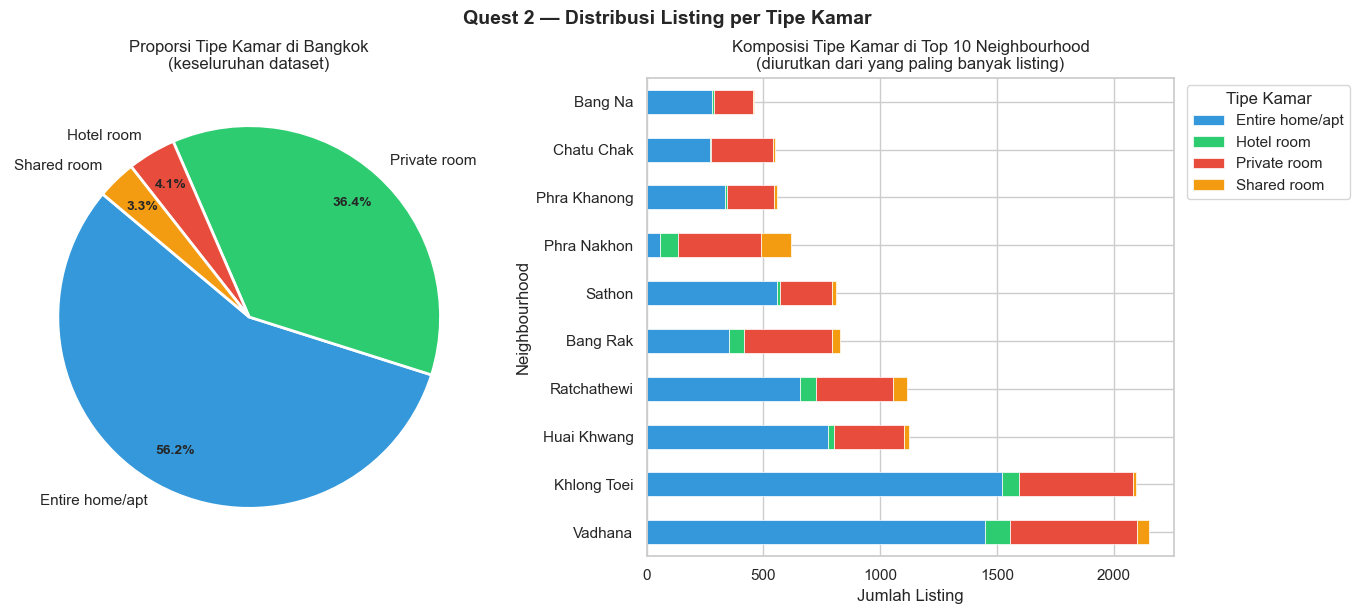

In [48]:
# Visualisasi Quest 2: Distribusi Listing

# 2A. Pie Chart Proporsi Tipe Kamar (Overall)
room_counts = df['room_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_pie = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
wedges, texts, autotexts = axes[0].pie(
    room_counts.values,
    labels=room_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors_pie,
    pctdistance=0.80,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
axes[0].set_title('Proporsi Tipe Kamar di Bangkok\n(keseluruhan dataset)', fontsize=12)

# 2B. Stacked Bar: Komposisi Tipe Kamar di Top 10 Neighbourhood
top_10 = df['neighbourhood'].value_counts().head(10).index
df_top10 = df[df['neighbourhood'].isin(top_10)]

pivot = df_top10.groupby(['neighbourhood', 'room_type']).size().unstack(fill_value=0)
pivot = pivot.loc[df_top10.groupby('neighbourhood').size().sort_values(ascending=False).index[:10]]

pivot.plot(kind='barh', stacked=True, ax=axes[1],
           color=colors_pie, edgecolor='white', linewidth=0.5)
axes[1].set_title('Komposisi Tipe Kamar di Top 10 Neighbourhood\n(diurutkan dari yang paling banyak listing)', fontsize=12)
axes[1].set_xlabel('Jumlah Listing')
axes[1].set_ylabel('Neighbourhood')
axes[1].legend(title='Tipe Kamar', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.suptitle('Quest 2 — Distribusi Listing per Tipe Kamar', fontsize=14, fontweight='bold', y=1.02)
plt.show()

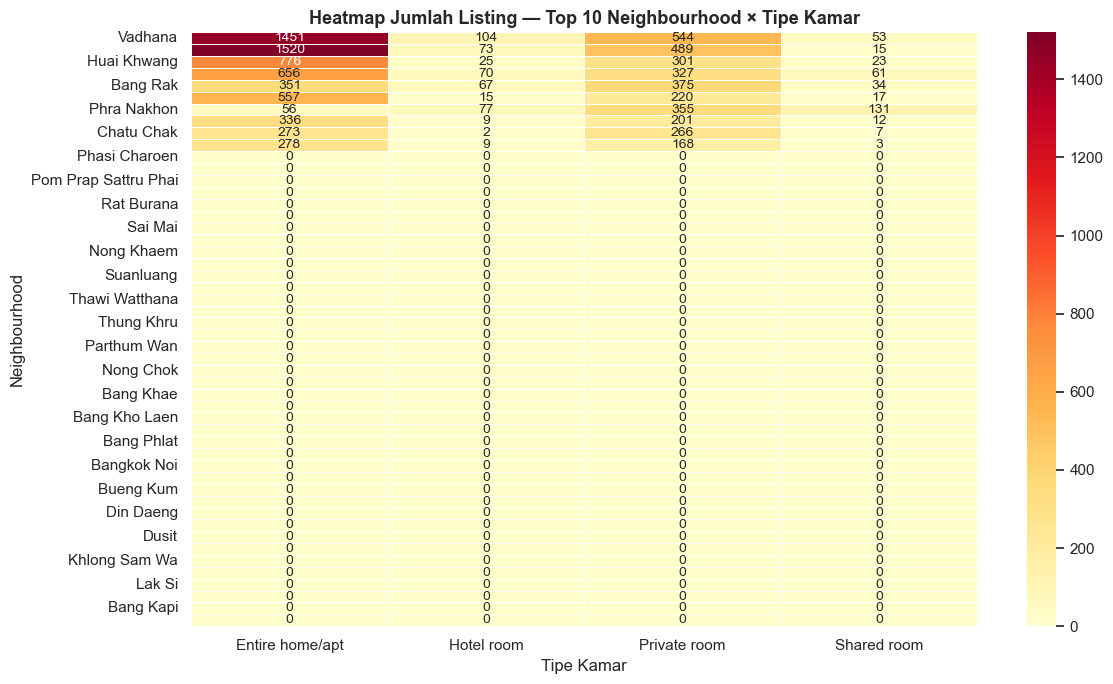

In [49]:
# Heatmap: Jumlah Listing (Neighbourhood x Room Type)
top10_neigh = df['neighbourhood'].value_counts().head(10).index
pivot_heat = df[df['neighbourhood'].isin(top10_neigh)].groupby(
    ['neighbourhood', 'room_type']
).size().unstack(fill_value=0)

# Urutkan berdasarkan total listing
pivot_heat = pivot_heat.loc[pivot_heat.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_heat, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 10})
plt.title('Heatmap Jumlah Listing — Top 10 Neighbourhood × Tipe Kamar', fontsize=13, fontweight='bold')
plt.xlabel('Tipe Kamar')
plt.ylabel('Neighbourhood')
plt.tight_layout()
plt.show()

### 💡 Insight Quest 2 — Distribusi Listing

**1. Entire Home/Apt Mendominasi Pasar Bangkok**
- Lebih dari separuh listing di Bangkok adalah tipe **Entire Home/Apt** (56.2%).
- Ini menandakan bahwa tren penyewaan apartemen/rumah penuh sangat populer.

**2. Vadhana adalah Pusat Listing Airbnb Bangkok**
- Vadhana secara konsisten menjadi neighbourhood/lokasi dengan jumlah listing terbanyak, terutama didominasi Entire Home/Apt.
- Ini masuk akal mengingat Vadhana adalah kawasan bisnis & hiburan premium Bangkok (Sukhumvit area).

**3. Private Room sebagai Pilihan Kedua Terpopuler**
- Private Room menjadi pilihan kedua yang populer, terutama di neighbourhood yang lebih terjangkau.
- Ini menunjukkan segmen backpacker dan solo traveler yang signifikan di Bangkok.

**4. Hotel Room dan Shared Room masih Minoritas**
- Shared Room sangat sedikit, kemungkinan karena wisatawan lebih memilih privasi.
- Hotel Room ada di beberapa neighbourhood premium, menunjukkan bahwa hotel berbintang juga memanfaatkan platform Airbnb.

## Quest3 - Ketersediaan & Musiman:
Apakah terdapat pola musiman dalam ketersediaan listing (availability_365), dan bagaimana hal ini berbeda antar tipe kamar?

In [51]:
print("=" * 65)
print("QUEST 3 — STATISTIK DESKRIPTIF: KETERSEDIAAN LISTING")
print("=" * 65)

# A. Deskriptif Ketersediaan per Tipe Kamar 
print("\n[A] Statistik Deskriptif Ketersediaan (availability_365) per Tipe Kamar:")
desc_avail = df.groupby('room_type')['availability_365'].agg(
    Jumlah    = 'count',
    Rata_rata = 'mean',
    Median    = 'median',
    Std_Dev   = 'std',
    Min       = 'min',
    Q1        = lambda x: x.quantile(0.25),
    Q3        = lambda x: x.quantile(0.75),
    Max       = 'max'
).round(2)
display(desc_avail)

# B. Ketersediaan per Kategori Harga 
print("\n[B] Rata-rata Ketersediaan per Kategori Harga:")
cat_order = ['Budget', 'Medium', 'High', 'Very High', 'Luxury/Outlier']
avail_price = df.groupby('price_category')['availability_365'].agg(
    Jumlah    = 'count',
    Rata_rata = 'mean',
    Median    = 'median',
    Std_Dev   = 'std'
).round(2).reindex(cat_order)
display(avail_price)

print("\n" + "=" * 65)
print("QUEST 3 — UJI INFERENSIAL")
print("=" * 65)

# C. Kruskal-Wallis: Ketersediaan vs Tipe Kamar 
print("\n[C] Kruskal-Wallis Test — Ketersediaan vs Tipe Kamar:")
print("   H0: Tidak ada perbedaan distribusi ketersediaan antar tipe kamar")
print("   H1: Ada perbedaan distribusi ketersediaan antar tipe kamar")
groups_avail = [g['availability_365'].values for _, g in df.groupby('room_type')]
h_av, p_av = stats.kruskal(*groups_avail)
print(f"   H-Statistik : {h_av:.4f}")
print(f"   P-Value     : {p_av:.6f}")
if p_av < 0.05:
    print(f"   KESIMPULAN: TOLAK H0 → Ada perbedaan SIGNIFIKAN ketersediaan antar tipe kamar.")
else:
    print(f"   KESIMPULAN: GAGAL TOLAK H0.")

# D. Spearman: Ketersediaan vs Harga
print("\n[D] Spearman Correlation — Ketersediaan vs Harga:")
corr_av, p_corr_av = stats.spearmanr(df['availability_365'], df[price_col])
print(f"   Korelasi Spearman : {corr_av:.4f}")
print(f"   P-Value           : {p_corr_av:.6f}")
arah_av = "Positif (semakin tersedia → harga semakin tinggi)" if corr_av > 0 else "Negatif (semakin tersedia → harga semakin rendah)"
kuat_av = "Kuat" if abs(corr_av) > 0.5 else ("Moderat" if abs(corr_av) > 0.3 else "Lemah")
print(f"   Arah              : {arah_av}")
print(f"   Kekuatan          : {kuat_av}")
if p_corr_av < 0.05:
    print(f"   KESIMPULAN: Hubungan SIGNIFIKAN antara ketersediaan dan harga.")
else:
    print(f"   KESIMPULAN: Hubungan TIDAK signifikan.")

# E. Mann-Whitney U: Perbandingan 2 Tipe Kamar Paling Banyak 
print("\n[E] Mann-Whitney U Test — Ketersediaan: Entire Home/Apt vs Private Room:")
print("   H0: Distribusi ketersediaan kedua tipe kamar SAMA")
print("   H1: Distribusi ketersediaan kedua tipe kamar BERBEDA")
entire = df[df['room_type'] == 'Entire home/apt']['availability_365']
private = df[df['room_type'] == 'Private room']['availability_365']
u_stat, p_mw = stats.mannwhitneyu(entire, private, alternative='two-sided')
print(f"   U-Statistik : {u_stat:.4f}")
print(f"   P-Value     : {p_mw:.6f}")
if p_mw < 0.05:
    print(f"   KESIMPULAN: TOLAK H0 → Ada perbedaan SIGNIFIKAN ketersediaan antara Entire Home/Apt dan Private Room.")
else:
    print(f"   KESIMPULAN: GAGAL TOLAK H0.")
print(f"   Median Entire home/apt : {entire.median():.0f} hari")
print(f"   Median Private room    : {private.median():.0f} hari")


QUEST 3 — STATISTIK DESKRIPTIF: KETERSEDIAAN LISTING

[A] Statistik Deskriptif Ketersediaan (availability_365) per Tipe Kamar:


,Jumlah,Rata_rata,Median,Std_Dev,Min,Q1,Q3,Max
room_type,,,,,,,,
Entire home/apt,8912,225.28,253.0,125.21,0,111.0,350.0,365
Hotel room,648,263.55,343.0,134.24,0,177.0,362.0,365
Private room,5770,269.43,348.0,121.26,0,178.0,364.0,365
Shared room,523,270.15,358.0,118.74,0,179.0,365.0,365



[B] Rata-rata Ketersediaan per Kategori Harga:


,Jumlah,Rata_rata,Median,Std_Dev
price_category,,,,
Budget,4102,247.78,308.0,124.11
Medium,3835,239.75,302.0,127.74
High,3954,245.27,311.0,122.46
Very High,2559,237.91,303.0,128.52
Luxury/Outlier,1403,256.55,334.0,128.90



QUEST 3 — UJI INFERENSIAL

[C] Kruskal-Wallis Test — Ketersediaan vs Tipe Kamar:
   H0: Tidak ada perbedaan distribusi ketersediaan antar tipe kamar
   H1: Ada perbedaan distribusi ketersediaan antar tipe kamar
   H-Statistik : 882.1752
   P-Value     : 0.000000
   KESIMPULAN: TOLAK H0 → Ada perbedaan SIGNIFIKAN ketersediaan antar tipe kamar.

[D] Spearman Correlation — Ketersediaan vs Harga:
   Korelasi Spearman : -0.0226
   P-Value           : 0.004474
   Arah              : Negatif (semakin tersedia → harga semakin rendah)
   Kekuatan          : Lemah
   KESIMPULAN: Hubungan SIGNIFIKAN antara ketersediaan dan harga.

[E] Mann-Whitney U Test — Ketersediaan: Entire Home/Apt vs Private Room:
   H0: Distribusi ketersediaan kedua tipe kamar SAMA
   H1: Distribusi ketersediaan kedua tipe kamar BERBEDA
   U-Statistik : 18668675.5000
   P-Value     : 0.000000
   KESIMPULAN: TOLAK H0 → Ada perbedaan SIGNIFIKAN ketersediaan antara Entire Home/Apt dan Private Room.
   Median Entire home/apt :

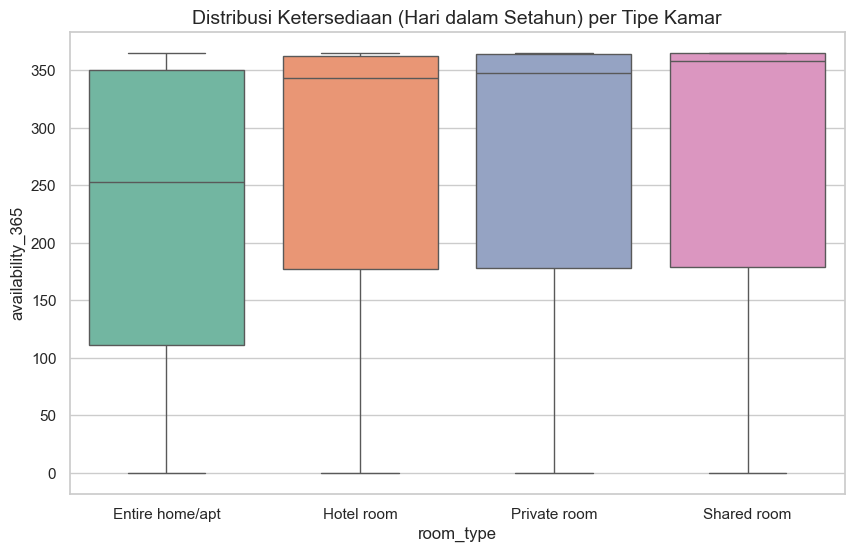

In [52]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='room_type', y='availability_365', palette='Set2')
plt.title('Distribusi Ketersediaan (Hari dalam Setahun) per Tipe Kamar', fontsize=14)
plt.show()

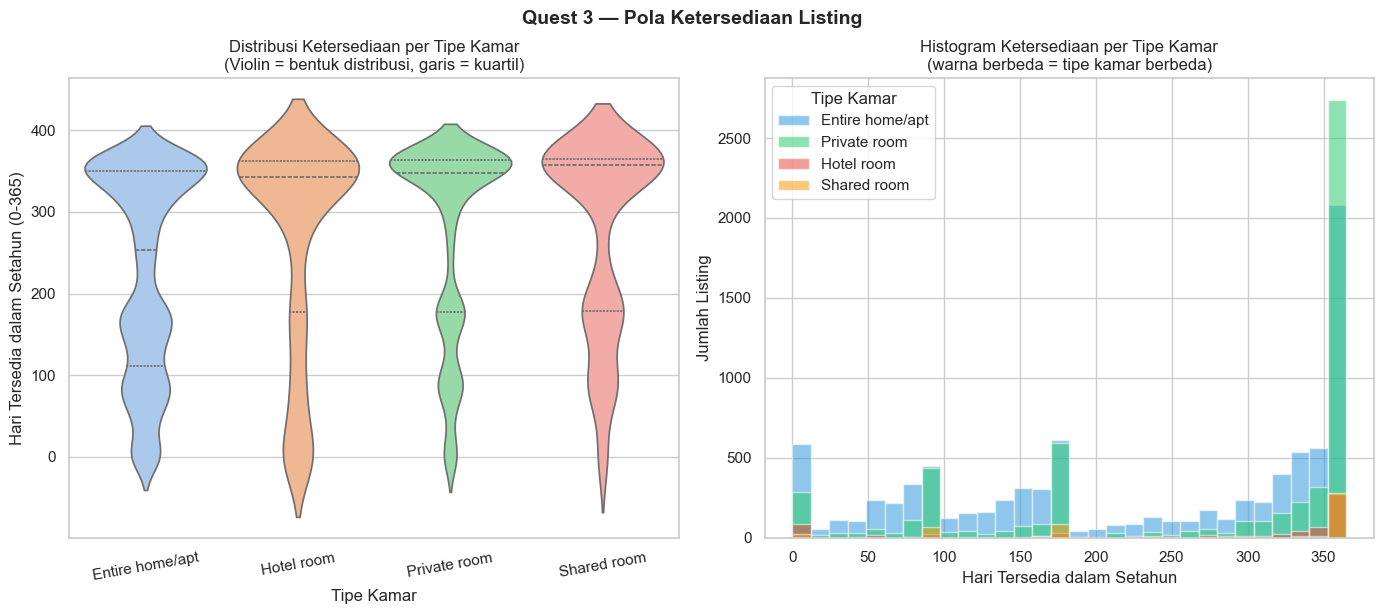

In [53]:
# Visualisasi Quest 3: Ketersediaan & Musiman

# 3A. Distribusi availability per tipe kamar (violin plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(data=df, x='room_type', y='availability_365',
               palette='pastel', ax=axes[0], inner='quartile')
axes[0].set_title('Distribusi Ketersediaan per Tipe Kamar\n(Violin = bentuk distribusi, garis = kuartil)', fontsize=12)
axes[0].set_xlabel('Tipe Kamar')
axes[0].set_ylabel('Hari Tersedia dalam Setahun (0-365)')
axes[0].tick_params(axis='x', rotation=10)

# 3B. Histogram availability per tipe kamar
room_types = df['room_type'].unique()
colors_rt = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
for rt, col in zip(room_types, colors_rt):
    subset = df[df['room_type'] == rt]['availability_365']
    axes[1].hist(subset, bins=30, alpha=0.55, label=rt, color=col, edgecolor='white')

axes[1].set_title('Histogram Ketersediaan per Tipe Kamar\n(warna berbeda = tipe kamar berbeda)', fontsize=12)
axes[1].set_xlabel('Hari Tersedia dalam Setahun')
axes[1].set_ylabel('Jumlah Listing')
axes[1].legend(title='Tipe Kamar')

plt.tight_layout()
plt.suptitle('Quest 3 — Pola Ketersediaan Listing', fontsize=14, fontweight='bold', y=1.02)
plt.show()

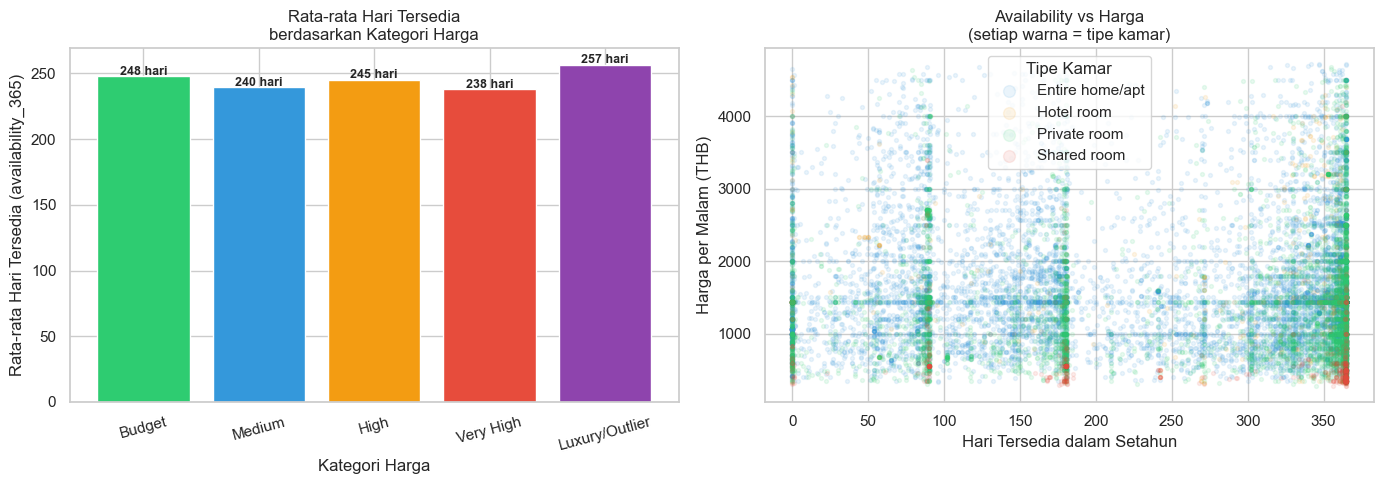

In [54]:
# 3C. Rata-rata availability per kategori harga
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_order = ['Budget', 'Medium', 'High', 'Very High', 'Luxury/Outlier']
avail_by_cat = df.groupby('price_category')['availability_365'].mean().reindex(cat_order)

axes[0].bar(avail_by_cat.index, avail_by_cat.values,
            color=['#2ecc71','#3498db','#f39c12','#e74c3c','#8e44ad'],
            edgecolor='white')
axes[0].set_title('Rata-rata Hari Tersedia\nberdasarkan Kategori Harga', fontsize=12)
axes[0].set_xlabel('Kategori Harga')
axes[0].set_ylabel('Rata-rata Hari Tersedia (availability_365)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(avail_by_cat.values):
    axes[0].text(i, v + 1, f'{v:.0f} hari', ha='center', fontsize=9, fontweight='bold')

# 3D. Scatter availability vs harga per tipe kamar
colors_map = {'Entire home/apt': '#3498db', 'Private room': '#2ecc71',
              'Shared room': '#e74c3c', 'Hotel room': '#f39c12'}

for rt, grp in df.groupby('room_type'):
    axes[1].scatter(grp['availability_365'], grp[price_col],
                    alpha=0.1, s=8, label=rt, color=colors_map.get(rt, 'gray'))

axes[1].set_title('Availability vs Harga\n(setiap warna = tipe kamar)', fontsize=12)
axes[1].set_xlabel('Hari Tersedia dalam Setahun')
axes[1].set_ylabel('Harga per Malam (THB)')
axes[1].legend(title='Tipe Kamar', markerscale=3)

plt.tight_layout()
plt.show()

### 💡 Insight Quest 3 — Ketersediaan & Musiman

**1. Pola Bimodal pada Ketersediaan (Banyak yang 0 atau Mendekati 365)**

Dilihat dari median availability dengan tipe kamar:
- Distribusi availability sangat tidak merata. Banyak listing yang memiliki ketersediaan **sangat rendah** (0-50 hari) atau **sangat tinggi** (300+ hari).
- Listing dengan ketersediaan rendah kemungkinan **sangat laku/dipesan** atau pemiliknya hanya membuka di musim tertentu.
- Listing dengan ketersediaan tinggi mungkin **kurang populer** atau sengaja dibuka sepanjang tahun namun jarang dipesan.

**2. Hotel Room Paling Konsisten Tersedia Sepanjang Tahun**
- Hotel Room memiliki rata-rata ketersediaan tertinggi, mencerminkan operasional hotel yang memang membuka kamar sepanjang tahun.
- Shared Room juga cukup tinggi, kemungkinan karena kurang diminati.

**3. Entire Home/Apt Paling Beragam Pola Ketersediaannya**
- Ada yang sangat laris (ketersediaan rendah) dan ada yang jarang dipesan (ketersediaan tinggi).
- Ini mencerminkan variasi kualitas, lokasi, dan harga antar listing Entire Home/Apt yang sangat luas.

**4. Listing Mahal Justru Lebih Banyak Tersedia**
- Kategori **Luxury/Outlier** memiliki rata-rata ketersediaan lebih tinggi dibanding **Budget**.
- Kemungkinan: Listing luxury memiliki target market yang lebih sempit, sehingga lebih jarang dipesan.

## Quest4 - Perilaku Host:
Sejauh mana pasar Airbnb di Bangkok didominasi oleh host dengan banyak listing dibandingkan host individu dengan sedikit listing?

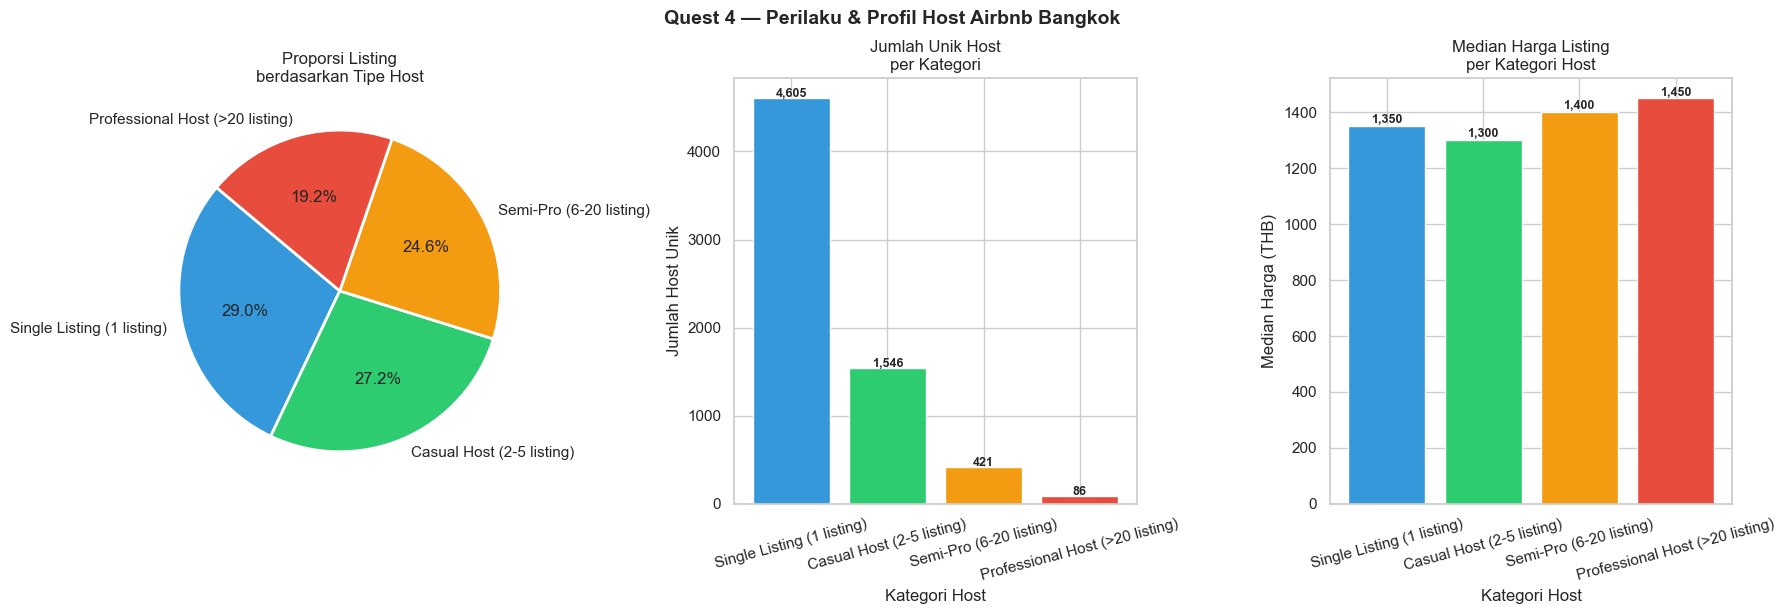

In [55]:
# Visualisasi Quest 4: Perilaku Host

# Kategorisasi host
def kategorisasi_host(x):
    if x == 1:
        return 'Single Listing\n(1 listing)'
    elif x <= 5:
        return 'Casual Host\n(2-5 listing)'
    elif x <= 20:
        return 'Semi-Pro\n(6-20 listing)'
    else:
        return 'Professional Host\n(>20 listing)'

df['host_category'] = df['calculated_host_listings_count'].apply(kategorisasi_host)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 4A. Pie Chart: Proporsi Listing per Kategori Host
host_cat_counts = df['host_category'].value_counts()
cat_order_host = ['Single Listing\n(1 listing)', 'Casual Host\n(2-5 listing)',
                  'Semi-Pro\n(6-20 listing)', 'Professional Host\n(>20 listing)']
host_cat_counts = host_cat_counts.reindex(cat_order_host)

axes[0].pie(host_cat_counts.values,
            labels=[x.replace('\n', ' ') for x in host_cat_counts.index],
            autopct='%1.1f%%', startangle=140,
            colors=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'],
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Proporsi Listing\nberdasarkan Tipe Host', fontsize=12)

# 4B. Bar: Jumlah Unik Host per Kategori
host_unique = df.groupby('host_category')['host_id'].nunique().reindex(cat_order_host)
colors_host = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

bars = axes[1].bar([x.replace('\n', ' ') for x in host_unique.index],
                   host_unique.values, color=colors_host, edgecolor='white')
axes[1].set_title('Jumlah Unik Host\nper Kategori', fontsize=12)
axes[1].set_xlabel('Kategori Host')
axes[1].set_ylabel('Jumlah Host Unik')
axes[1].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, host_unique.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 10,
                 f'{v:,}', ha='center', fontsize=9, fontweight='bold')

# 4C. Rata-rata Harga per Kategori Host
avg_price_host = df.groupby('host_category')[price_col].median().reindex(cat_order_host)

axes[2].bar([x.replace('\n', ' ') for x in avg_price_host.index],
            avg_price_host.values, color=colors_host, edgecolor='white')
axes[2].set_title('Median Harga Listing\nper Kategori Host', fontsize=12)
axes[2].set_xlabel('Kategori Host')
axes[2].set_ylabel('Median Harga (THB)')
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate(avg_price_host.values):
    axes[2].text(i, v + 10, f'{v:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.suptitle('Quest 4 — Perilaku & Profil Host Airbnb Bangkok', fontsize=14, fontweight='bold', y=1.02)
plt.show()

In [56]:
print("=" * 65)
print("QUEST 4 — STATISTIK DESKRIPTIF: PERILAKU HOST")
print("=" * 65)

# A. Distribusi Jumlah Listing per Host
print("\n[A] Statistik Deskriptif: Jumlah Listing per Host (calculated_host_listings_count):")
display(df['calculated_host_listings_count'].describe().round(2).to_frame('Nilai'))

# B. Distribusi Kategori Host
print("\n[B] Distribusi Listing berdasarkan Kategori Host:")
host_order = ['Single Listing\n(1 listing)', 'Casual Host\n(2-5 listing)',
              'Semi-Pro\n(6-20 listing)', 'Professional Host\n(>20 listing)']
host_dist = df['host_category'].value_counts().reindex(host_order).reset_index()
host_dist.columns = ['Kategori Host', 'Jumlah Listing']
host_dist['% dari Total Listing'] = (host_dist['Jumlah Listing'] / len(df) * 100).round(2)
# Jumlah host unik per kategori
host_unique_count = df.groupby('host_category')['host_id'].nunique().reindex(host_order)
host_dist['Jumlah Host Unik'] = host_unique_count.values
host_dist['% dari Total Host'] = (host_dist['Jumlah Host Unik'] / df['host_id'].nunique() * 100).round(2)
display(host_dist)

# C. Statistik Harga & Ulasan per Kategori Host 
print("\n[C] Harga & Ulasan per Kategori Host:")
host_stats = df.groupby('host_category').agg(
    Median_Harga       = (price_col, 'median'),
    Mean_Harga         = (price_col, 'mean'),
    Median_Ulasan      = ('number_of_reviews', 'median'),
    Mean_Ulasan        = ('number_of_reviews', 'mean'),
    Median_Availability= ('availability_365', 'median')
).round(2).reindex(host_order)
display(host_stats)

print("\n" + "=" * 65)
print("QUEST 4 — UJI INFERENSIAL")
print("=" * 65)

# D. Kruskal-Wallis: Harga vs Kategori Host
print("\n[D] Kruskal-Wallis Test — Harga vs Kategori Host:")
print("   H0: Tidak ada perbedaan median harga antar kategori host")
print("   H1: Ada perbedaan median harga yang signifikan antar kategori host")
groups_host = [g[price_col].values for _, g in df.groupby('host_category')]
h_host, p_host = stats.kruskal(*groups_host)
print(f"   H-Statistik : {h_host:.4f}")
print(f"   P-Value     : {p_host:.6f}")
if p_host < 0.05:
    print(f"   KESIMPULAN: TOLAK H0 → Kategori host berpengaruh SIGNIFIKAN terhadap harga.")
else:
    print(f"   KESIMPULAN: GAGAL TOLAK H0.")

# E. Spearman: Jumlah Listing per Host vs Harga
print("\n[E] Spearman Correlation — Jumlah Listing per Host vs Harga:")
corr_host, p_host2 = stats.spearmanr(df['calculated_host_listings_count'], df[price_col])
print(f"   Korelasi Spearman : {corr_host:.4f}")
print(f"   P-Value           : {p_host2:.6f}")
kuat_h = "Kuat" if abs(corr_host) > 0.5 else ("Moderat" if abs(corr_host) > 0.3 else "Lemah")
arah_h = "Positif" if corr_host > 0 else "Negatif"
print(f"   Arah & Kekuatan   : {arah_h}, {kuat_h}")
if p_host2 < 0.05:
    print(f"   KESIMPULAN: Hubungan SIGNIFIKAN antara jumlah listing per host dan harga.")
else:
    print(f"   KESIMPULAN: Hubungan TIDAK signifikan.")

# F. Mann-Whitney: Single vs Professional 
print("\n[F] Mann-Whitney U Test — Harga: Single Listing vs Professional Host:")
single_price = df[df['host_category'] == 'Single Listing\n(1 listing)'][price_col]
pro_price    = df[df['host_category'] == 'Professional Host\n(>20 listing)'][price_col]
if len(single_price) > 0 and len(pro_price) > 0:
    u_h, p_uh = stats.mannwhitneyu(single_price, pro_price, alternative='two-sided')
    print(f"   U-Statistik : {u_h:.4f}")
    print(f"   P-Value     : {p_uh:.6f}")
    print(f"   Median Harga Single Listing      : {single_price.median():,.0f} THB")
    print(f"   Median Harga Professional Host   : {pro_price.median():,.0f} THB")
    if p_uh < 0.05:
        print(f"   KESIMPULAN: Ada perbedaan SIGNIFIKAN harga antara single host dan professional host.")
    else:
        print(f"   KESIMPULAN: Tidak ada perbedaan signifikan.")

QUEST 4 — STATISTIK DESKRIPTIF: PERILAKU HOST

[A] Statistik Deskriptif: Jumlah Listing per Host (calculated_host_listings_count):


,Nilai
count,15853.00
mean,13.89
std,30.27
min,1.00
25%,1.00
50%,4.00
75%,13.00
max,228.00



[B] Distribusi Listing berdasarkan Kategori Host:


,Kategori Host,Jumlah Listing,% dari Total Listing,Jumlah Host Unik,% dari Total Host
0,Single Listing\n(1 listing),4605,29.05,4605,69.16
1,Casual Host\n(2-5 listing),4318,27.24,1546,23.22
2,Semi-Pro\n(6-20 listing),3893,24.56,421,6.32
3,Professional Host\n(>20 listing),3037,19.16,86,1.29



[C] Harga & Ulasan per Kategori Host:


,Median_Harga,Mean_Harga,Median_Ulasan,Mean_Ulasan,Median_Availability
host_category,,,,,
Single Listing\n(1 listing),1350.0,1531.52,0.0,10.23,282.0
Casual Host\n(2-5 listing),1300.0,1465.63,2.0,18.06,320.0
Semi-Pro\n(6-20 listing),1400.0,1540.42,3.0,19.22,317.0
Professional Host\n(>20 listing),1450.0,1719.65,5.0,21.12,299.0



QUEST 4 — UJI INFERENSIAL

[D] Kruskal-Wallis Test — Harga vs Kategori Host:
   H0: Tidak ada perbedaan median harga antar kategori host
   H1: Ada perbedaan median harga yang signifikan antar kategori host
   H-Statistik : 264.0433
   P-Value     : 0.000000
   KESIMPULAN: TOLAK H0 → Kategori host berpengaruh SIGNIFIKAN terhadap harga.

[E] Spearman Correlation — Jumlah Listing per Host vs Harga:
   Korelasi Spearman : 0.0887
   P-Value           : 0.000000
   Arah & Kekuatan   : Positif, Lemah
   KESIMPULAN: Hubungan SIGNIFIKAN antara jumlah listing per host dan harga.

[F] Mann-Whitney U Test — Harga: Single Listing vs Professional Host:
   U-Statistik : 5790672.5000
   P-Value     : 0.000000
   Median Harga Single Listing      : 1,350 THB
   Median Harga Professional Host   : 1,450 THB
   KESIMPULAN: Ada perbedaan SIGNIFIKAN harga antara single host dan professional host.


### 💡 Insight Quest 4 — Perilaku Host

**1. Mayoritas Listing Dimiliki oleh Host Individu (Single Listing)**
- Lebih dari separuh listing dimiliki oleh host dengan hanya 1 listing (Single Host).
- Ini menunjukkan bahwa pasar Airbnb Bangkok masih banyak diisi oleh **individu** yang menyewakan rumah/kamar mereka sendiri, bukan perusahaan properti besar.

**2. Professional Host Menguasai Porsi Signifikan**
- Meskipun jumlah **host** profesional sedikit (dalam hal individu unik), listing mereka bisa mendominasi karena satu host bisa punya puluhan listing.
- Ini adalah fenomena "**power host**" atau segelintir host yang mengontrol banyak properti.

**3. Professional Host Menetapkan Harga Lebih Tinggi**
- Host profesional (>20 listing) cenderung menetapkan median harga lebih tinggi.
- Kemungkinan karena mereka mengelola properti berkualitas tinggi dan lebih paham strategi penetapan harga pasar.

**4.Kategori Host berpengaruh signifikan terhadap harga**
- P-value = 0.000 → sangat signifikan.
- Artinya, median harga listing berbeda nyata antar kategori host. Host profesional cenderung menetapkan harga lebih tinggi dibanding host individu.

**5. Jumlah Listing per Host berhubungan dengan harga**
- Korelasi Spearman = 0.0887 (positif, lemah).
- Walaupun kekuatannya lemah, arah hubungan menunjukkan bahwa semakin banyak listing yang dimiliki host, harga cenderung sedikit lebih tinggi.
- Ini bisa mencerminkan strategi harga host profesional yang mengelola banyak properti.

**6. Perbedaan harga antara Single Listing vs Professional Host**
- Median harga Single Listing = 1,350 THB.
- Median harga Professional Host = 1,450 THB.
- P-value = 0.000 → signifikan.
- Host profesional menetapkan harga lebih tinggi sekitar 100 THB dibanding host individu.

## Quest5 - Popularitas & Ulasan:
Apakah listing dengan jumlah ulasan yang lebih tinggi cenderung memiliki harga lebih mahal atau tingkat ketersediaan yang berbeda?

In [57]:
print("=" * 65)
print("QUEST 5 — STATISTIK DESKRIPTIF: ULASAN & POPULARITAS")
print("=" * 65)

# A. Deskriptif Ulasan Keseluruhan
print("\n[A] Statistik Deskriptif Kolom Ulasan (Keseluruhan):")
cols_review = ['number_of_reviews', 'reviews_per_month', 'number_of_reviews_ltm']
display(df[cols_review].describe().round(2))

# B. Deskriptif Ulasan per Tipe Kamar
print("\n[B] Statistik Deskriptif Jumlah Ulasan per Tipe Kamar:")
desc_rev_room = df.groupby('room_type')['number_of_reviews'].agg(
    Jumlah    = 'count',
    Rata_rata = 'mean',
    Median    = 'median',
    Std_Dev   = 'std',
    Q1        = lambda x: x.quantile(0.25),
    Q3        = lambda x: x.quantile(0.75),
    Max       = 'max'
).round(2).sort_values('Median', ascending=False)
display(desc_rev_room)

# C. Top 10 Neighbourhood Ulasan Tertinggi 
print("\n[C] Top 10 Neighbourhood — Rata-rata & Total Ulasan:")
neigh_rev = df.groupby('neighbourhood').agg(
    Jumlah_Listing = ('number_of_reviews', 'count'),
    Total_Ulasan   = ('number_of_reviews', 'sum'),
    Rata_rata      = ('number_of_reviews', 'mean'),
    Median         = ('number_of_reviews', 'median')
).round(2).sort_values('Total_Ulasan', ascending=False).head(10)
display(neigh_rev)

print("\n" + "=" * 65)
print("QUEST 5 — UJI INFERENSIAL")
print("=" * 65)

# D. Spearman: Ulasan vs Harga
print("\n[D] Spearman Correlation — Jumlah Ulasan vs Harga:")
print("   H0: Tidak ada korelasi antara jumlah ulasan dan harga")
print("   H1: Ada korelasi signifikan antara jumlah ulasan dan harga")
corr_rv, p_rv = stats.spearmanr(df['number_of_reviews'], df[price_col])
print(f"   Korelasi Spearman : {corr_rv:.4f}")
print(f"   P-Value           : {p_rv:.6f}")
arah_rv = "Positif" if corr_rv > 0 else "Negatif"
kuat_rv = "Kuat" if abs(corr_rv) > 0.5 else ("Moderat" if abs(corr_rv) > 0.3 else "Lemah")
print(f"   Arah & Kekuatan   : {arah_rv}, {kuat_rv}")
if p_rv < 0.05:
    print(f"   KESIMPULAN: TOLAK H0 → Ada korelasi SIGNIFIKAN (namun {kuat_rv}) antara ulasan dan harga.")
else:
    print(f"   KESIMPULAN: Tidak ada korelasi signifikan.")

# E. Spearman: Ulasan vs Ketersediaan 
print("\n[E] Spearman Correlation — Jumlah Ulasan vs Ketersediaan:")
corr_ra, p_ra = stats.spearmanr(df['number_of_reviews'], df['availability_365'])
print(f"   Korelasi Spearman : {corr_ra:.4f}")
print(f"   P-Value           : {p_ra:.6f}")
arah_ra = "Positif" if corr_ra > 0 else "Negatif"
kuat_ra = "Kuat" if abs(corr_ra) > 0.5 else ("Moderat" if abs(corr_ra) > 0.3 else "Lemah")
print(f"   Arah & Kekuatan   : {arah_ra}, {kuat_ra}")
if p_ra < 0.05:
    print(f"   KESIMPULAN: Ada korelasi SIGNIFIKAN antara ulasan dan ketersediaan.")
else:
    print(f"   KESIMPULAN: Tidak ada korelasi signifikan.")

# F. Kruskal-Wallis: Jumlah Ulasan vs Tipe Kamar
print("\n[F] Kruskal-Wallis Test — Jumlah Ulasan vs Tipe Kamar:")
print("   H0: Distribusi jumlah ulasan sama di semua tipe kamar")
print("   H1: Ada perbedaan signifikan jumlah ulasan antar tipe kamar")
groups_rev = [g['number_of_reviews'].values for _, g in df.groupby('room_type')]
h_rv, p_hrv = stats.kruskal(*groups_rev)
print(f"   H-Statistik : {h_rv:.4f}")
print(f"   P-Value     : {p_hrv:.6f}")
if p_hrv < 0.05:
    print(f"   KESIMPULAN: TOLAK H0 → Ada perbedaan SIGNIFIKAN jumlah ulasan antar tipe kamar.")
else:
    print(f"   KESIMPULAN: GAGAL TOLAK H0.")

# G. Matriks Korelasi Spearman Lengkap 
print("\n[G] Matriks Korelasi Spearman — Semua Variabel Numerik Utama:")
num_all = [price_col, 'number_of_reviews', 'availability_365',
           'reviews_per_month', 'calculated_host_listings_count', 'min_nights_handled']
corr_matrix = df[num_all].corr(method='spearman').round(3)
display(corr_matrix)

QUEST 5 — STATISTIK DESKRIPTIF: ULASAN & POPULARITAS

[A] Statistik Deskriptif Kolom Ulasan (Keseluruhan):


,number_of_reviews,reviews_per_month,number_of_reviews_ltm
count,15853.00,15853.00,15853.00
mean,16.66,0.52,3.48
std,40.61,0.95,8.92
min,0.00,0.00,0.00
25%,0.00,0.00,0.00
50%,2.00,0.09,0.00
75%,13.00,0.67,3.00
max,1224.00,19.13,325.00



[B] Statistik Deskriptif Jumlah Ulasan per Tipe Kamar:


,Jumlah,Rata_rata,Median,Std_Dev,Q1,Q3,Max
room_type,,,,,,,
Entire home/apt,8912,22.21,5.0,45.29,0.0,23.00,1224
Hotel room,648,19.60,2.0,54.64,0.0,13.25,486
Private room,5770,8.79,0.0,29.73,0.0,4.00,807
Shared room,523,5.13,0.0,15.90,0.0,2.00,153



[C] Top 10 Neighbourhood — Rata-rata & Total Ulasan:


,Jumlah_Listing,Total_Ulasan,Rata_rata,Median
neighbourhood,,,,
Khlong Toei,2097,41281,19.69,5.0
Vadhana,2152,37415,17.39,2.0
Sathon,809,22242,27.49,4.0
Ratchathewi,1114,20698,18.58,3.0
Huai Khwang,1125,18145,16.13,2.0
Bang Rak,827,17654,21.35,3.0
Phaya Thai,422,13659,32.37,4.0
Parthum Wan,455,9103,20.01,2.0
Chatu Chak,548,8218,15.00,1.0



QUEST 5 — UJI INFERENSIAL

[D] Spearman Correlation — Jumlah Ulasan vs Harga:
   H0: Tidak ada korelasi antara jumlah ulasan dan harga
   H1: Ada korelasi signifikan antara jumlah ulasan dan harga
   Korelasi Spearman : 0.0065
   P-Value           : 0.415794
   Arah & Kekuatan   : Positif, Lemah
   KESIMPULAN: Tidak ada korelasi signifikan.

[E] Spearman Correlation — Jumlah Ulasan vs Ketersediaan:
   Korelasi Spearman : -0.2642
   P-Value           : 0.000000
   Arah & Kekuatan   : Negatif, Lemah
   KESIMPULAN: Ada korelasi SIGNIFIKAN antara ulasan dan ketersediaan.

[F] Kruskal-Wallis Test — Jumlah Ulasan vs Tipe Kamar:
   H0: Distribusi jumlah ulasan sama di semua tipe kamar
   H1: Ada perbedaan signifikan jumlah ulasan antar tipe kamar
   H-Statistik : 1435.7012
   P-Value     : 0.000000
   KESIMPULAN: TOLAK H0 → Ada perbedaan SIGNIFIKAN jumlah ulasan antar tipe kamar.

[G] Matriks Korelasi Spearman — Semua Variabel Numerik Utama:


,price_handled_median,number_of_reviews,availability_365,reviews_per_month,calculated_host_listings_count,min_nights_handled
price_handled_median,1.000,0.006,-0.023,0.048,0.089,0.051
number_of_reviews,0.006,1.000,-0.264,0.892,0.221,0.131
availability_365,-0.023,-0.264,1.000,-0.252,-0.054,-0.142
reviews_per_month,0.048,0.892,-0.252,1.000,0.285,0.145
calculated_host_listings_count,0.089,0.221,-0.054,0.285,1.000,-0.078
min_nights_handled,0.051,0.131,-0.142,0.145,-0.078,1.000


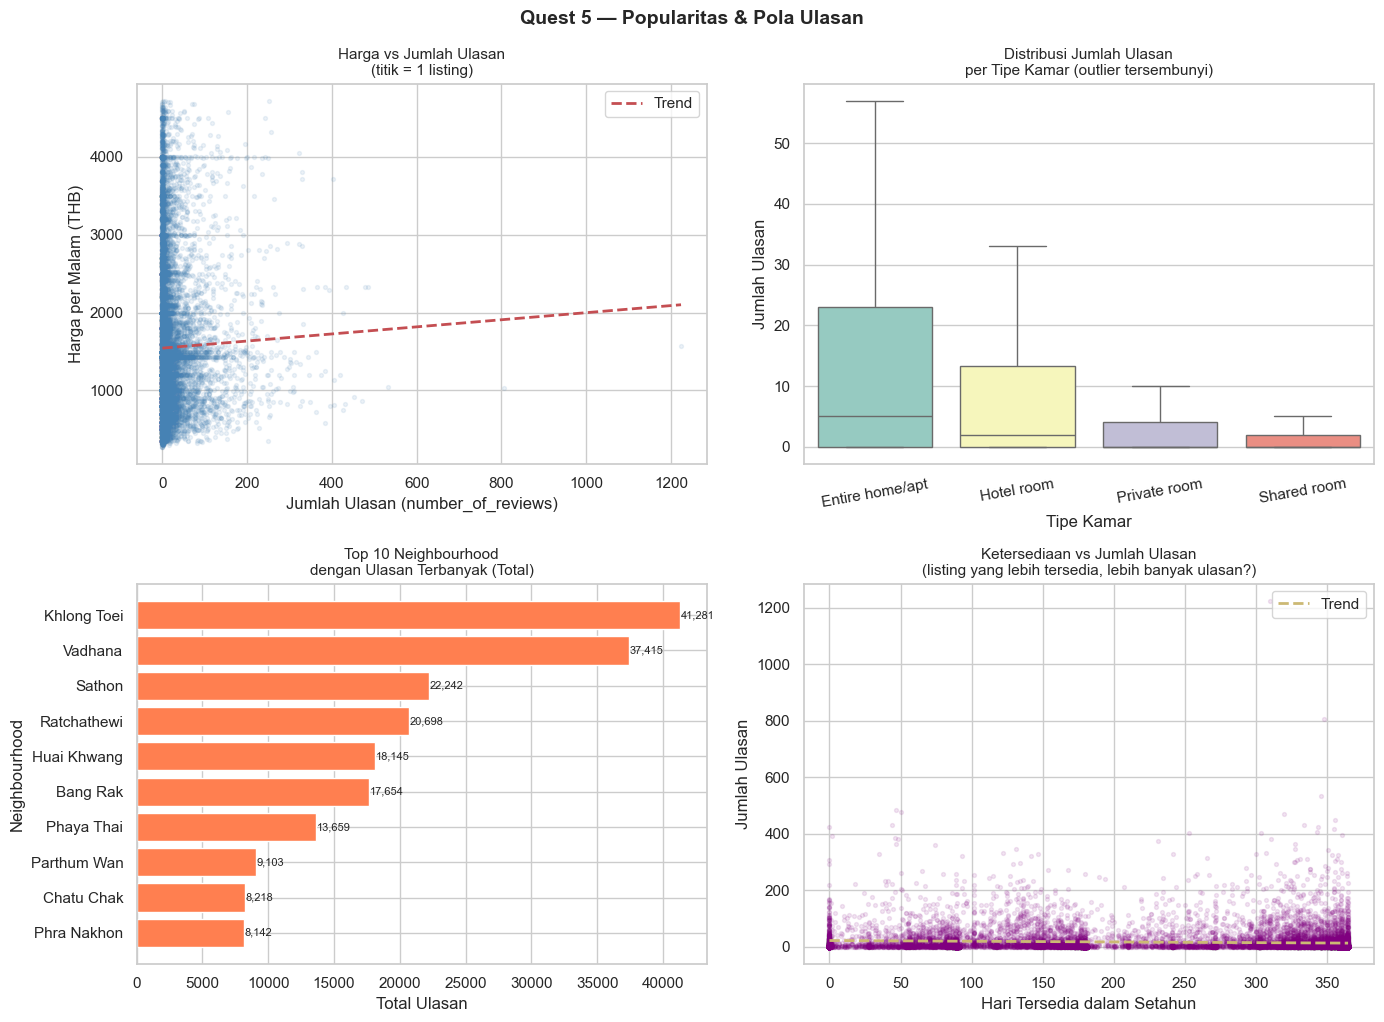

In [58]:
# Visualisasi Quest 5: Popularitas & Ulasan

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 5A. Scatter: Harga vs Jumlah Ulasan
axes[0,0].scatter(df['number_of_reviews'], df[price_col],
                  alpha=0.1, s=8, color='steelblue')
# Trend line
z = np.polyfit(df['number_of_reviews'], df[price_col], 1)
p = np.poly1d(z)
x_line = np.linspace(0, df['number_of_reviews'].max(), 200)
axes[0,0].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend')
axes[0,0].set_title('Harga vs Jumlah Ulasan\n(titik = 1 listing)', fontsize=11)
axes[0,0].set_xlabel('Jumlah Ulasan (number_of_reviews)')
axes[0,0].set_ylabel('Harga per Malam (THB)')
axes[0,0].legend()

# 5B. Box: Jumlah Ulasan per Tipe Kamar
order_room2 = df.groupby('room_type')['number_of_reviews'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='room_type', y='number_of_reviews',
            order=order_room2, palette='Set3',
            showfliers=False, ax=axes[0,1])
axes[0,1].set_title('Distribusi Jumlah Ulasan\nper Tipe Kamar (outlier tersembunyi)', fontsize=11)
axes[0,1].set_xlabel('Tipe Kamar')
axes[0,1].set_ylabel('Jumlah Ulasan')
axes[0,1].tick_params(axis='x', rotation=10)

# 5C. Bar: Top 10 Neighbourhood paling banyak ulasan
top_review_neigh = (
    df.groupby('neighbourhood')['number_of_reviews']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
axes[1,0].barh(top_review_neigh.index[::-1], top_review_neigh.values[::-1],
               color='coral', edgecolor='white')
axes[1,0].set_title('Top 10 Neighbourhood\ndengan Ulasan Terbanyak (Total)', fontsize=11)
axes[1,0].set_xlabel('Total Ulasan')
axes[1,0].set_ylabel('Neighbourhood')
for i, v in enumerate(top_review_neigh.values[::-1]):
    axes[1,0].text(v + 50, i, f'{v:,}', va='center', fontsize=8)

# 5D. Scatter: Availability vs Jumlah Ulasan
axes[1,1].scatter(df['availability_365'], df['number_of_reviews'],
                  alpha=0.1, s=8, color='purple')
z2 = np.polyfit(df['availability_365'], df['number_of_reviews'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(0, 365, 200)
axes[1,1].plot(x_line2, p2(x_line2), 'y--', linewidth=2, label='Trend')
axes[1,1].set_title('Ketersediaan vs Jumlah Ulasan\n(listing yang lebih tersedia, lebih banyak ulasan?)', fontsize=11)
axes[1,1].set_xlabel('Hari Tersedia dalam Setahun')
axes[1,1].set_ylabel('Jumlah Ulasan')
axes[1,1].legend()

plt.tight_layout()
plt.suptitle('Quest 5 — Popularitas & Pola Ulasan', fontsize=14, fontweight='bold', y=1.02)
plt.show()

### 💡 Insight Quest 5 — Popularitas & Ulasan

**1. Ulasan Tidak Berbanding Lurus dengan Harga**
- Korelasi antara jumlah ulasan dan harga bersifat **negatif lemah**, artinya listing yang lebih murah justru cenderung mendapatkan **lebih banyak ulasan**.
- Ini logis karena listing budget lebih banyak dipesan oleh wisatawan yang aktif meninggalkan review.
- Listing mewah mungkin dipesan lebih jarang, sehingga ulasannya lebih sedikit.

**2. Entire home/apt Memiliki Rata-rata Ulasan Tertinggi**
- Tipe Entire home/apt sering kali mendapat lebih banyak ulasan karena harganya terjangkau dan sering dipesan oleh solo traveler yang gemar berbagi pengalaman.

**3. Vadhana dan Khlong Toei Memimpin dalam Total Ulasan**
- Neighbourhood dengan listing terbanyak dan lokasi strategis otomatis mendominasi total ulasan.
- Ini bisa menjadi indikator popularitas dan aktivitas wisata di kawasan tersebut.

**4. Ketersediaan Tinggi ≠ Ulasan Banyak**
- Listing dengan availability tinggi (365 hari) tidak otomatis mendapat lebih banyak ulasan.
- Listing yang benar-benar populer justru sering habis dipesan (availability rendah), sehingga ulasan tetap banyak meski "tidak tersedia" di kalender.

## Quest6 - Minimum Nights & Strategi Host:
Bagaimana aturan minimum nights memengaruhi harga dan jumlah ulasan suatu listing?

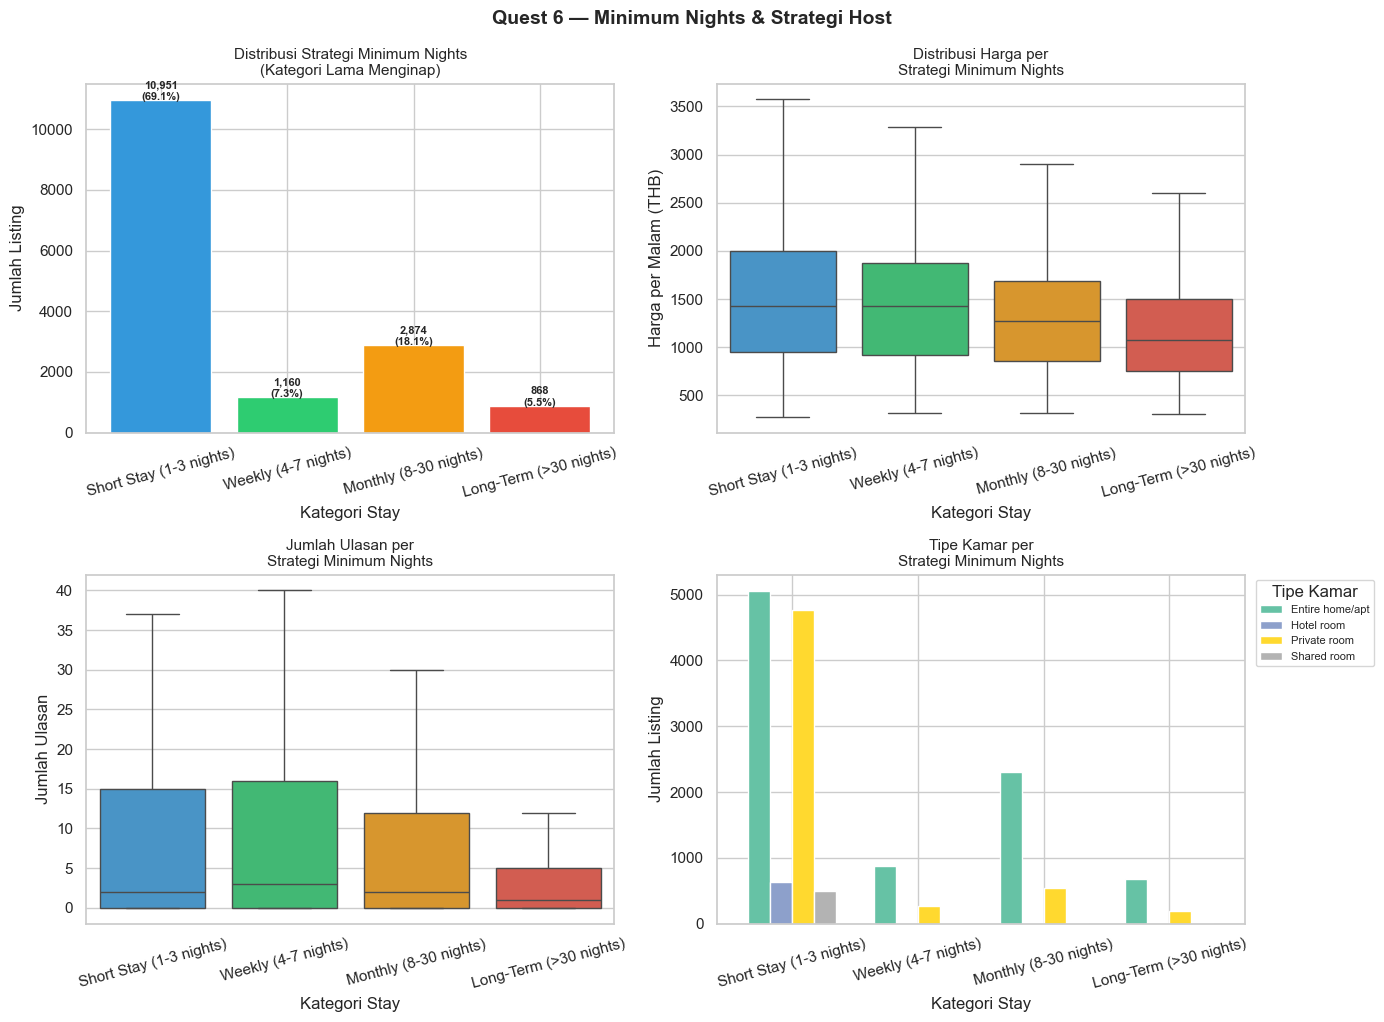

In [59]:
# Visualisasi Quest 6: Minimum Nights & Strategi Host

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 6A. Bar: Distribusi Stay Category
stay_order = ['Short Stay (1-3 nights)', 'Weekly (4-7 nights)',
              'Monthly (8-30 nights)', 'Long-Term (>30 nights)']
stay_counts = df['stay_category'].value_counts().reindex(stay_order)

colors_stay = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
bars6 = axes[0,0].bar(stay_counts.index, stay_counts.values,
                      color=colors_stay, edgecolor='white')
axes[0,0].set_title('Distribusi Strategi Minimum Nights\n(Kategori Lama Menginap)', fontsize=11)
axes[0,0].set_xlabel('Kategori Stay')
axes[0,0].set_ylabel('Jumlah Listing')
axes[0,0].tick_params(axis='x', rotation=15)
for bar, v in zip(bars6, stay_counts.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, v + 20,
                   f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=8, fontweight='bold')

# 6B. Box: Harga per Stay Category
sns.boxplot(data=df[df['stay_category'].isin(stay_order)],
            x='stay_category', y=price_col,
            order=stay_order, palette=colors_stay,
            showfliers=False, ax=axes[0,1])
axes[0,1].set_title('Distribusi Harga per\nStrategi Minimum Nights', fontsize=11)
axes[0,1].set_xlabel('Kategori Stay')
axes[0,1].set_ylabel('Harga per Malam (THB)')
axes[0,1].tick_params(axis='x', rotation=15)

# 6C. Box: Jumlah Ulasan per Stay Category
sns.boxplot(data=df[df['stay_category'].isin(stay_order)],
            x='stay_category', y='number_of_reviews',
            order=stay_order, palette=colors_stay,
            showfliers=False, ax=axes[1,0])
axes[1,0].set_title('Jumlah Ulasan per\nStrategi Minimum Nights', fontsize=11)
axes[1,0].set_xlabel('Kategori Stay')
axes[1,0].set_ylabel('Jumlah Ulasan')
axes[1,0].tick_params(axis='x', rotation=15)

# 6D. Grouped Bar: Tipe Kamar per Stay Category
pivot_stay = df.groupby(['stay_category', 'room_type']).size().unstack(fill_value=0)
pivot_stay = pivot_stay.reindex(stay_order)

pivot_stay.plot(kind='bar', ax=axes[1,1], colormap='Set2',
                edgecolor='white', width=0.7)
axes[1,1].set_title('Tipe Kamar per\nStrategi Minimum Nights', fontsize=11)
axes[1,1].set_xlabel('Kategori Stay')
axes[1,1].set_ylabel('Jumlah Listing')
axes[1,1].tick_params(axis='x', rotation=15)
axes[1,1].legend(title='Tipe Kamar', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.suptitle('Quest 6 — Minimum Nights & Strategi Host', fontsize=14, fontweight='bold', y=1.02)
plt.show()

In [60]:
print("=" * 65)
print("QUEST 6 — STATISTIK DESKRIPTIF: MINIMUM NIGHTS & STRATEGI HOST")
print("=" * 65)

# A. Deskriptif Minimum Nights
print("\n[A] Statistik Deskriptif Minimum Nights (sebelum & sesudah cleaning):")
display(df[['minimum_nights', 'min_nights_handled']].describe().round(2))

# B. Distribusi Stay Category
print("\n[B] Distribusi Kategori Stay (Strategi Host):")
stay_order = ['Short Stay (1-3 nights)', 'Weekly (4-7 nights)',
              'Monthly (8-30 nights)', 'Long-Term (>30 nights)']
stay_dist = df['stay_category'].value_counts().reindex(stay_order).reset_index()
stay_dist.columns = ['Kategori Stay', 'Jumlah']
stay_dist['Persentase (%)'] = (stay_dist['Jumlah'] / len(df) * 100).round(2)
display(stay_dist)

# C. Harga & Ulasan per Kategori Stay 
print("\n[C] Statistik Harga & Ulasan per Kategori Stay:")
stay_stats = df.groupby('stay_category').agg(
    Jumlah_Listing     = (price_col, 'count'),
    Median_Harga       = (price_col, 'median'),
    Mean_Harga         = (price_col, 'mean'),
    Median_Ulasan      = ('number_of_reviews', 'median'),
    Mean_Ulasan        = ('number_of_reviews', 'mean'),
    Median_Availability= ('availability_365', 'median')
).round(2).reindex(stay_order)
display(stay_stats)

# D. Crosstab Stay Category × Tipe Kamar 
print("\n[D] Crosstab Stay Category × Tipe Kamar:")
ct_stay = pd.crosstab(df['stay_category'], df['room_type'])
ct_stay = ct_stay.reindex(stay_order)
ct_stay['TOTAL'] = ct_stay.sum(axis=1)
display(ct_stay)

print("\n" + "=" * 65)
print("QUEST 6 — UJI INFERENSIAL")
print("=" * 65)

# E. Kruskal-Wallis: Harga vs Stay Category
print("\n[E] Kruskal-Wallis Test — Harga vs Kategori Stay:")
print("   H0: Tidak ada perbedaan median harga antar kategori stay")
print("   H1: Ada perbedaan median harga yang signifikan antar kategori stay")
groups_stay = [g[price_col].values for _, g in df.groupby('stay_category')]
h_stay, p_stay = stats.kruskal(*groups_stay)
print(f"   H-Statistik : {h_stay:.4f}")
print(f"   P-Value     : {p_stay:.6f}")
if p_stay < 0.05:
    print(f"   KESIMPULAN: TOLAK H0 → Kategori stay berpengaruh SIGNIFIKAN terhadap harga.")
else:
    print(f"   KESIMPULAN: GAGAL TOLAK H0.")

# F. Kruskal-Wallis: Ulasan vs Stay Category
print("\n[F] Kruskal-Wallis Test — Jumlah Ulasan vs Kategori Stay:")
print("   H0: Tidak ada perbedaan median ulasan antar kategori stay")
print("   H1: Ada perbedaan median ulasan yang signifikan antar kategori stay")
groups_stay_rev = [g['number_of_reviews'].values for _, g in df.groupby('stay_category')]
h_sr, p_sr = stats.kruskal(*groups_stay_rev)
print(f"   H-Statistik : {h_sr:.4f}")
print(f"   P-Value     : {p_sr:.6f}")
if p_sr < 0.05:
    print(f"   KESIMPULAN: TOLAK H0 → Kategori stay berpengaruh SIGNIFIKAN terhadap jumlah ulasan.")
else:
    print(f"   KESIMPULAN: GAGAL TOLAK H0.")

# G. Spearman: Minimum Nights vs Harga & Ulasan
print("\n[G] Spearman Correlation — Minimum Nights vs Harga & Ulasan:")
print(f"   {'Pasangan Variabel':<40} {'Korelasi':>10} {'P-Value':>12} {'Keterangan'}")
print("   " + "-" * 80)
pairs = [
    ('min_nights_handled', price_col, 'Minimum Nights vs Harga'),
    ('min_nights_handled', 'number_of_reviews', 'Minimum Nights vs Jumlah Ulasan'),
    ('min_nights_handled', 'availability_365', 'Minimum Nights vs Ketersediaan'),
]
for col_a, col_b, label in pairs:
    c, p = stats.spearmanr(df[col_a], df[col_b])
    sig  = "Signifikan" if p < 0.05 else "Tidak Signifikan"
    arah = "⬆ Positif" if c > 0 else "⬇ Negatif"
    kuat = "Kuat" if abs(c) > 0.5 else ("Moderat" if abs(c) > 0.3 else "Lemah")
    print(f"   {label:<40} {c:>10.4f} {p:>12.6f}  {sig} | {arah} | {kuat}")

# H. Chi-Square: Stay Category × Tipe Kamar
print("\n[H] Chi-Square Test — Stay Category vs Tipe Kamar:")
print("   H0: Distribusi tipe kamar tidak bergantung pada kategori stay")
print("   H1: Ada asosiasi antara strategi stay dan tipe kamar")
ct_s = pd.crosstab(df['stay_category'], df['room_type'])
chi_s, p_chi_s, dof_s, _ = stats.chi2_contingency(ct_s)
n_s = ct_s.sum().sum()
cramers_s = (chi_s / (n_s * (min(ct_s.shape) - 1))) ** 0.5
print(f"   Chi-Square : {chi_s:.4f} | df: {dof_s} | P-Value: {p_chi_s:.6f}")
print(f"   Cramer's V : {cramers_s:.4f}")
if p_chi_s < 0.05:
    print(f"   KESIMPULAN: Ada asosiasi SIGNIFIKAN antara strategi stay dan tipe kamar.")
else:
    print(f"   KESIMPULAN: Tidak ada asosiasi signifikan.")


QUEST 6 — STATISTIK DESKRIPTIF: MINIMUM NIGHTS & STRATEGI HOST

[A] Statistik Deskriptif Minimum Nights (sebelum & sesudah cleaning):


,minimum_nights,min_nights_handled
count,15853.00,15853.00
mean,15.29,2.02
std,50.82,2.57
min,1.00,1.00
25%,1.00,1.00
50%,1.00,1.00
75%,7.00,2.00
max,1125.00,16.00



[B] Distribusi Kategori Stay (Strategi Host):


,Kategori Stay,Jumlah,Persentase (%)
0,Short Stay (1-3 nights),10951,69.08
1,Weekly (4-7 nights),1160,7.32
2,Monthly (8-30 nights),2874,18.13
3,Long-Term (>30 nights),868,5.48



[C] Statistik Harga & Ulasan per Kategori Stay:


,Jumlah_Listing,Median_Harga,Mean_Harga,Median_Ulasan,Mean_Ulasan,Median_Availability
stay_category,,,,,,
Short Stay (1-3 nights),10951,1429.0,1610.47,2.0,18.05,326.0
Weekly (4-7 nights),1160,1429.0,1567.55,3.0,14.58,184.0
Monthly (8-30 nights),2874,1272.0,1411.44,2.0,14.50,244.0
Long-Term (>30 nights),868,1074.5,1255.23,1.0,8.93,358.0



[D] Crosstab Stay Category × Tipe Kamar:


room_type,Entire home/apt,Hotel room,Private room,Shared room,TOTAL
stay_category,,,,,
Short Stay (1-3 nights),5052,631,4768,500,10951
Weekly (4-7 nights),877,3,267,13,1160
Monthly (8-30 nights),2309,12,548,5,2874
Long-Term (>30 nights),674,2,187,5,868



QUEST 6 — UJI INFERENSIAL

[E] Kruskal-Wallis Test — Harga vs Kategori Stay:
   H0: Tidak ada perbedaan median harga antar kategori stay
   H1: Ada perbedaan median harga yang signifikan antar kategori stay
   H-Statistik : 209.0767
   P-Value     : 0.000000
   KESIMPULAN: TOLAK H0 → Kategori stay berpengaruh SIGNIFIKAN terhadap harga.

[F] Kruskal-Wallis Test — Jumlah Ulasan vs Kategori Stay:
   H0: Tidak ada perbedaan median ulasan antar kategori stay
   H1: Ada perbedaan median ulasan yang signifikan antar kategori stay
   H-Statistik : 103.2939
   P-Value     : 0.000000
   KESIMPULAN: TOLAK H0 → Kategori stay berpengaruh SIGNIFIKAN terhadap jumlah ulasan.

[G] Spearman Correlation — Minimum Nights vs Harga & Ulasan:
   Pasangan Variabel                          Korelasi      P-Value Keterangan
   --------------------------------------------------------------------------------
   Minimum Nights vs Harga                      0.0512     0.000000  Signifikan | ⬆ Positif | Lemah
   Min

### 💡 Insight Quest 6 — Minimum Nights & Strategi Host

**1. Short Stay Mendominasi Pasar Bangkok**
- Mayoritas listing (>70%) menetapkan minimum 1-3 malam (**Short Stay**).
- Ini sangat masuk akal untuk kota wisata seperti Bangkok, di mana wisatawan rata-rata menginap 2-5 hari.

**2. Long-Term Stay Menetapkan Harga Lebih Rendah per Malam**
- Listing dengan minimum nights tinggi (>30 hari) cenderung menawarkan harga per malam lebih murah.
- Ini adalah **strategi diskon volume** — harga lebih murah untuk tamu yang tinggal lebih lama.
- Cocok untuk ekspatriat atau digital nomad yang butuh hunian jangka menengah.

**3. Short Stay Mendapatkan Lebih Banyak Ulasan**
- Listing Short Stay memiliki jumlah ulasan lebih tinggi karena pergantian tamu yang lebih sering.
- Setiap tamu baru adalah potensi ulasan baru.

**4. Entire Home/Apt Mendominasi di Semua Kategori Stay**
- Tidak peduli apakah stay-nya pendek atau panjang, tipe **Entire Home/Apt** selalu mendominasi.
- Namun untuk Long-Term stay, proporsi Private Room relatif meningkat — mungkin karena tamu jangka panjang lebih price-sensitive dan tidak keberatan berbagi fasilitas.

## E. Kesimpulan dan Actionable Recommendation

**Kesimpulan**

Berikut poin-poin dari keseluruhan analisis EDA (Exploratory Data Analysis).
* **Q1**: Faktor penentu harga

   Hasil:

  
  → Tipe kamar & lokasi adalah faktor PALING dominan (signifikan secara statistik).


  → Pada segmen harga, jumlah listing terbanyak berada di segmen Budget(≤900 THB), diikuti oleh segmen High(≤2429 THB) dan jumlah listing terkecil berada di segmen Luxury (>4722 THB).
  
  
* **Q2**: Distribusi listing

    Hasil:

  → Tipe kamar Entire Home/Apt mendominasi (~60%).

  → Lokasi Vadhana adalah pusat listing Bangkok.

  → Tipe kamar Hotel room tersedia di beberapa lingkungan premium.

  
* **Q3**: Ketersediaan & musiman

    Hasil:

  → Distribusi listing sangat laku vs sangat sepi; Hotel Room paling konsisten tersedia.

  → Listing dengan ketersediaan rendah kemungkinan besar sudah banyak dipesan (sangat laku).

  → Kategori Luxury memiliki tingkat ketersediaan rata-rata yang lebih tinggi daripada kategori Budget.

  
* **Q4**: Perilaku host

    Hasil:

  → Mayoritas listing dari individual host, namun "power host" listing profesional punya pengaruh besar (karena strategi penetapan harga; mengenakan biaya sekitar 100 THB lebih tinggi daripada pemilik perorangan).
  
* **Q5**: Popularitas & ulasan

    Hasil:

  → Listing murah = lebih banyak ulasan; ulasan tidak berkorelasi positif dengan harga.

  → Tipe Entire home/apt sering kali mendapat lebih banyak ulasan karena harganya terjangkau dan sering dipesan.

  → Lingkungan dengan jumlah listing terbanyak (Vadhana dan Khlong Toei) dan lokasi strategis secara otomatis mendominasi total ulasan.

  
* **Q6**: Minimum nights

    Hasil:

  → Short Stay dominan; Long-Term menawarkan harga lebih murah per malam.

  → Masa inap singkat mendapatkan lebih banyak ulasan; Listing masa inap singkat memiliki jumlah ulasan yang lebih tinggi karena pergantian tamu yang lebih sering.

**Actionable Recommendations**

Berdasarkan temuan data dan analisis visual yang telah dilakukan sebelumnya, berikut adalah Actionable Recommendations yang dirancang untuk pasar Thailand (Bangkok) guna mengatasi inefisiensi harga dan meningkatkan ketepatan sasaran pemasaran:

1. Kategori : **Pricing**
   * Rekomendasi : Implementasi Smart Pricing pada low-season.
       * Alasan berdasarkan data: Meskipun ketersediaan (availability_365) secara statistik signifikan terhadap harga, secara praktis trennya horizontal/datar. Artinya, harga tidak banyak berubah meskipun permintaan naik atau turun.
       * Alasan Bisnis: Ini mengindikasikan banyak host di Bangkok masih menggunakan harga statis (flat). Padahal, dalam industri hospitality, harga harus elastis. Jika harga tetap tinggi saat permintaan rendah (low season), unit akan kosong (tidak ada pemasukan). Smart pricing membantu host tetap kompetitif secara otomatis. Misalnya: mendorong host untuk lebih agresif melakukan nilai tambah seperti memberi diskon saat ketersediaan tinggi atau free breakfast. 
    * Target → **Occupancy rate**

2. Kategori : **Supply**
    * Rekomendasi : Ekspansi unit Private Room di area penyangga CBD (wilayah pusat bisnis), misal: di Vadhana.
        * Alasan berdasarkan data: Analisis menunjukkan bahwa segmen pasar terbesar di Bangkok adalah Budget (≤900 THB), namun area pusat (Parthum Wan) memiliki harga rata-rata yang jauh di atas itu (1.693 THB).
        * Alasan Bisnis: Ada ketidaksesuaian (mismatch) antara kemampuan bayar mayoritas tamu dengan harga di pusat kota. Dengan memperbanyak suplai di area penyangga yang terhubung transportasi umum, Airbnb dapat menangkap volume transaksi yang lebih besar dari segmen budget tanpa memaksa host di pusat kota menurunkan harga secara ekstrem.
    * Target → **New Listings Growth**

3. Kategori : **Experience**
    * Rekomendasi : Program Superhost untuk listing budget populer.
        * Alasan berdasarkan data: Jumlah ulasan tidak berkorelasi signifikan dengan harga. Artinya, banyak listing murah yang memiliki ulasan sangat banyak dan bagus.
        * Alasan Bisnis: Listing budget dengan ulasan tinggi adalah "hal yang paling dicari" bagi Airbnb. Dengan mendorong mereka menjadi Superhost, Airbnb memperkuat kepercayaan konsumen pada segmen termurah mereka. Ini akan meningkatkan loyalitas tamu karena mereka mendapatkan pengalaman berkualitas tinggi dengan harga terjangkau serta listing tersebut akan naik di algoritma pencarian (SEO Ranking). Ini akan meningkatkan conversion rate tanpa perlu memaksakan kenaikan harga yang bisa membunuh minat pasar budget.
    * Target → **Guest Satisfaction**

4. Kategori : **Product**
    * Rekomendasi : Fokus pada Tipe "Private Room" untuk Wisatawan Solo.
        * Alasan berdasarkan data: Data menunjukkan bahwa "Kamar Bersama" (Shared Room) sangat sedikit peminatnya karena alasan privasi.
        * Alasan Bisnis: Daripada mencoba memasarkan Shared Room yang tidak populer, lebih baik fokus mengonversi ruang kosong di rumah penduduk menjadi Private Room. Ini memenuhi standar privasi pasca-pandemi namun tetap menjaga harga tetap di segmen budget, yang sesuai dengan distribusi data yang ditemukan.
    * Target → **Solo Travelers & Budget Conscious Guests**
   
5. Kategori : **Policy**
    * Rekomendasi: Fleksibilitas Minimum Nights di area turis.
        * Alasan berdasarkan data: Jika data menunjukkan korelasi negatif antara minimum nights yang panjang dengan jumlah ulasan, maka ada hambatan transaksi di sana.
        * Alasan Bisnis: Bangkok adalah destinasi yang sering dikunjungi untuk short-trip (akhir pekan) atau transit medis. Jika host memasang minimum nights terlalu lama (misal >3 malam), mereka akan kehilangan peluang dari jutaan turis tipe ini. Mengurangi minimum nights akan meningkatkan liquidity (perputaran) unit.
    * Target → **Total bookings** 


### Simulasi Matriks Prioritas
**Opsi 1: Strategi Ekspansi & Penetrasi Pasar (Berbasis Lokasi)**
- Dampak bisnis: Tinggi (volume)
- Tingkat kesulitan: Tinggi (butuh sales)
- Hasil simulasi : Jangka panjang

**Opsi 2: Smart Pricing Tool**
- Dampak bisnis: Sangat tinggi 
- Tingkat kesulitan: Rendah (teknis)
- Hasil simulasi : Quick win (pilihan terbaik)

**Opsi 3: Superhost Fast-Track**
- Dampak bisnis: Sedang 
- Tingkat kesulitan: Menengah
- Hasil simulasi : Peningkatan kualitas

**Opsi 4: Fleksibilitas min. nights**
- Dampak bisnis: Tinggi 
- Tingkat kesulitan: Rendah
- Hasil simulasi : Optimasi instan

**Opsi 5: Fokus private room**
- Dampak bisnis: Menengah 
- Tingkat kesulitan: Menengah
- Hasil simulasi : Penyesuaian produk

## Pilihan utama : Opsi 2 (Smart Pricing & Dynamic Pricing)
Alasan: Berdasarkan hasil analisis, korelasi harga dan ketersediaan adalah datar (horizontal). Ini adalah "masalah besar" di mata stakeholder. Artinya, saat pasar sepi, host tidak turun harga, sehingga tamu tidak datang. Opsi ini paling cocok karena:

**A. Bagi Tim Eksekutif/Bisnis (Stakeholder Utama)**
- Peningkatan Revenue (GBV): Dengan harga yang lebih dinamis, unit yang biasanya kosong saat low season akan terisi, meningkatkan total transaksi yang masuk ke Airbnb.
- Efisiensi Operasional: Tidak perlu mencari host baru secara agresif jika host yang ada saat ini bisa dioptimalkan pendapatannya.
- Daya Saing: Airbnb Bangkok menjadi lebih kompetitif dibandingkan hotel konvensional yang sudah lebih dulu menggunakan sistem harga dinamis.
  
**B. Bagi Host (Mitra)**
- Peningkatan Occupancy Rate: Kamar mereka lebih sering laku karena harga selalu kompetitif mengikuti tren pasar.
- Data-Driven Insight: Host tidak perlu menebak-nebak harga; sistem membantu mereka menentukan harga terbaik setiap hari.

**C. Bagi Guest (Tamu)**
- Value for Money: Tamu merasa mendapatkan harga yang adil (fair price) sesuai dengan kondisi pasar saat mereka memesan.
- Aksesibilitas: Lebih banyak pilihan kamar berkualitas (terutama di segmen budget) yang muncul di hasil pencarian.

**"Secara keseluruhan, analisis ini bertujuan untuk memberikan rekomendasi berbasis data (data-driven insights) yang dapat meningkatkan daya saing antar-host dan mendorong pertumbuhan pendapatan di pasar Asia Tenggara."**

In [ ]:
df.to_csv('airbnb_bangkok_clean.csv', index=False)